# c-Fos Neural Network Analysis
### applied to Aboharb, Davoudian et al. (2025), *Nature Communications*

Biological questions and how this pipeline answers them
1. Do the drug conditions produce genuinely different brain network architectures, or is it just noise?
Question: are two groups' whole-brain correlation matrices more or less similar than would be expected by chance?
How: Mantel test — row/column permutation of one matrix (not cell-wise, which would ignore that matrix entries are not independent), comparing the observed correlation between the two matrices against a permuted null.
2. Does the specific arrangement of strong/weak connections matter, or is it just the overall strength of correlations?
Question: if the same edge weights were randomly reshuffled across different region pairs, would you get a similar communication-efficiency curve? Or is the specific topological arrangement (which regions are strong hubs) doing something beyond "how high are correlations overall"?
How: randomized-null disruption model (§12, new) — for each pairwise comparison, both groups' own edge weights are independently reassigned to random node pairs (randomize_edge_weights, preserves the exact weight distribution, destroys which-region-correlates-with-which structure), many times, GPU-batched the same way as the virtual-lesion analysis. A pointwise permutation test at each edge-count marks where each group's real curve exits the null band.
3. Which specific brain regions change hub status between conditions?
Question: for each individual region, does its network centrality differ between drugs by more than would be expected from randomly re-labelling which animal received which drug?
How: per-region permutation + BH-FDR correction — corrected across all 237 regions per (comparison, metric), unlike the original which had no correction at all and no region-level test in the first place.
Note on permutation count: with 237 regions tested at once, BH-FDR needs the single best region's raw p-value below FDR_ALPHA / 237 ≈ 0.00021 to survive correction, which needs n_perm >= ~4740 — below that, "0 significant regions" may simply mean the p-value floor (1/(n_perm+1)) was too coarse, not that there is no effect. §13 prints this calculation and warns explicitly when the configured n_perm_region can't reach it. Because betweenness costs ~30x more per permutation (it needs a full shortest-path pass), the practical default runs degree/closeness at a permutation count that can actually detect something, and leaves betweenness at a cheaper preview count, with the cost/power tradeoff spelled out so it can be bumped up for an overnight run.
How (visualization): the all-region centrality figure (§8 metrics, §15 figure) plots every region with bootstrap error bars (resampling animals, §9) and region names colour-coded by the smallest raw p-value across the three pairwise comparisons (green ≤0.01, orange ≤0.05, blue ≤0.1 — a visual guide, not FDR-corrected; see §13 for the corrected version).
4. If a given region were lesioned, how much would the network suffer — and where would it break?
Question: which regions are actually critical, not just inferred from centrality but directly tested by removing them?
How: virtual lesion analysis (v2.1) — each region is removed one at a time and the impact on the residual network is measured: functional (drop in global efficiency on the dense graph) and structural (does removing it fragment the backbone — an exact articulation-point test via networkx, not brute-force). Cheap (~9 s total), so it runs unconditionally. A permutation test on the correlation between two groups' impact vectors asks whether the same regions are critical across drugs (Figures 9-10, §14).
5. Is the apparent difference in communication efficiency between groups real, with only 4 animals/group?
Question: do the efficiency curves (strong/weak-link removal) show a genuine separation between groups, or is it sampling noise given the small sample?
How: bootstrap CI on the efficiency curves — animals are resampled with replacement to get an uncertainty band, instead of v1's single point estimate (which gave no way to tell real group separation from sampling noise).
6. Which broader brain system does each region belong to, so the network figures can be read in biological terms?
Question: the network figures (backbone, chord diagram) are only interpretable if you know whether a region is cortex, hippocampus, thalamus, etc.
How: anatomical categorization (§6, new) — regions are classified into major Allen CCF divisions (Isocortex, Hippocampal formation, Thalamus, Striatum, Midbrain, ...) by walking each region's ontology parent chain up to the nearest known major-division ID. This is an approximation, not a curated scheme — a region with no matching ancestor is labelled "Other", and the category counts are printed so a badly-matching atlas file is obvious immediately rather than silently mislabelled.
Statistical guardrails (not new questions, but they prevent wrong answers to the right question)
Within-group z-scores for centrality: on a near-complete graph, weighted degree and closeness saturate near 1.0 for almost every region — without the z-score, the risk is reading "hub" where it's really just graph saturation, not a real signal.
Cluster count annotated on the ARI (Figure 6): comparing a 2-cluster partition to an 8-cluster partition drives the ARI toward 0 almost by construction — on its own that is NOT evidence of different modular organisation, and the figure now says so explicitly instead of leaving it implicit.
Visible cluster-block outlines (Figure 1): against the diverging colormap, these were previously invisible.
Practical notes (not biological, but relevant to using the pipeline)
REPORT.md: every key number the wet-lab would want to quote, in one page, instead of having to derive them from six different CSVs.
GPU: every new heavy computation (disruption null model, per-region bootstrap) is GPU-batched. Betweenness stays CPU-bound by design — Brandes' dependency accumulation has a sequential structure that doesn't batch cleanly, and it isn't the pipeline's bottleneck anyway. Final figure rendering (matplotlib) is inherently CPU-bound regardless of backend, as in any pipeline.


## Parameter reference

Every tunable constant in this pipeline, where it's set, and what it controls.

### Paths and mode

| Parameter | Default | What it controls |
|---|---|---|
| `DATA_DIR` | `"."` | Folder with the Kwan-Lab CSVs and the atlas |
| `OUT_DIR` | `"./Brain_net_output"` | Output folder (figures, CSVs, REPORT.md) |
| `USE_SYNTHETIC_DEMO` | `False` | `True` = generate fake data for a quick smoke-test |
| `RANDOM_SEED` | `42` | Seed for every random operation (reproducibility) |
| `FDR_ALPHA` | `0.05` | Significance threshold for BH-FDR correction |

### Permutation / replicate counts (computational cost)

| Parameter | Default | Section | Note |
|---|---|---|---|
| `N_PERM` | `5000` | §13 | Whole-matrix permutation test — cheap |
| `MANTEL_N_PERM` | `5000` | §13 | Whole-matrix Mantel test — cheap |
| `N_PERM_REGION_CHEAP` | `5000` | §13 | Per-region permutation, wdeg/closeness (no shortest-path pass) |
| `N_PERM_REGION_BETWEENNESS` | `500` | §13 | Per-region permutation, betweenness — ~30x more expensive per iteration |
| `N_BOOTSTRAP` | `100` | §10 | Bootstrap CI on the efficiency curves |
| `N_BOOTSTRAP_CENTRALITY` | `100` | §9 | Bootstrap CI on per-region centrality |
| `N_DISRUPTION_NULL` | `100` | §12 | Randomized-null replicates, per direction |

> ⚠️ With 237 regions, `N_PERM_REGION_CHEAP`/`_BETWEENNESS` below ~4740 can make the test report "0 significant regions" simply because the p-value floor was too coarse, not because there's no effect — §13 calculates this and warns automatically.

### Edge-removal grids (curve resolution)

| Parameter | Default | What it controls |
|---|---|---|
| `REMOVAL_FRACS` | `linspace(0, 0.6, 31)` | Main grid (31 points, 0–60% edges removed) for the efficiency curves |
| `REMOVAL_FRACS_BOOTSTRAP` | `linspace(0, 0.6, 8)` | Coarser grid (8 points) used only for the bootstrap band |
| `DISRUPTION_FRACS` | `linspace(0, 0.6, 15)` | Grid (15 points) for the disruption null-model curves |

### On/off switches (gating expensive steps)

| Parameter | Default | What it disables if `False` |
|---|---|---|
| `ENABLE_REGION_STATS` | `True` | Per-region permutation + FDR (§13) |
| `ENABLE_REGION_BETWEENNESS` | `True` | Just the betweenness part of §13 (the expensive one) |
| `ENABLE_BOOTSTRAP_CI` | `True` | Bootstrap CI on the efficiency curves (§10) |
| `ENABLE_EL_BOOTSTRAP` | `True` | Bootstrap on local efficiency (costs more than global) |
| `ENABLE_CENTRALITY_BOOTSTRAP` | `True` | Bootstrap CI on per-region centrality (§9) |
| `ENABLE_CENTRALITY_BOOTSTRAP_BETWEENNESS` | `True` | Just the betweenness part of §9 |
| `ENABLE_DISRUPTION_NULL` | `True` | The entire disruption null model (§12) — no Fig.3 if `False` |

### Group metadata

| Parameter | Value |
|---|---|
| `DRUG_META` | `{'PSI': {'label': 'Psilocybin', 'color': '#006837'}, 'KET': {'label': 'Ketamine', 'color': '#8B1A4A'}, 'SAL': {'label': 'Saline', 'color': '#BBBBBB'}}` |
| `DRUG_ORDER` | `['PSI', 'KET', 'SAL']` |
| `COMPARISONS` | The 3 pairs derived from `DRUG_ORDER`: PSI–SAL, KET–SAL, PSI–KET |

### Statistical/algorithmic parameters embedded in functions

Not in the §1 settings block — pass them explicitly as function arguments if you want to change these.

| Parameter | Default | Where | What it controls |
|---|---|---|---|
| `MAX_ABS_R` | `0.9999` | §2 | Clip on \|r\| before `-ln\|r\|` — avoids the singularity at \|r\|=1 |
| `MIN_ABS_R` | `1e-12` | §2 | Minimum clip on \|r\| |
| `gammas` (Voronoi) | `linspace(0.5, 3.0, 15)` | §7 | Clustering resolution, scanned to maximize Q |
| `NBR_QUANTILES` | `(0.02, 0.05, 0.10, 0.20, 0.35, 0.50)` | §7 | Neighbourhood sizes scanned in Voronoi clustering |
| `min_giant` | `0.5` | §11 | Giant-component threshold that stops backbone extraction |
| `top_frac` | `0.05` | §15 (chord diagram) | Fraction of strongest edges shown in the chord diagram (top 5% by \|r\|) |

## 1 · Imports and compute backend

In [1]:
"""
Murgia et al. (2026) methodology - applied to Aboharb, Davoudian et al. (2025)
=============================================================================
Per-group Pearson -> weighted graph -> Voronoi clustering -> centrality
(l_ij = -ln|w_ij|) -> E_g/E_l communication efficiency -> backbone extraction
-> permutation testing -> between-condition statistics -> figures.
"""
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.path as mpath
from matplotlib.patches import Rectangle, FancyBboxPatch, PathPatch
import seaborn as sns
from scipy.sparse.csgraph import floyd_warshall
from scipy.stats import rankdata
from sklearn.metrics import adjusted_rand_score
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

try:
    get_ipython()                                        # noqa: F821
    IN_NOTEBOOK = True
except NameError:
    IN_NOTEBOOK = False
    matplotlib.use('Agg')


# ---------------------------------------------------------------- GPU backend
def _init_backend():
    """Select CuPy only if a CUDA device is actually usable (probed, not just imported)."""
    try:
        import cupy as cp
        if cp.cuda.runtime.getDeviceCount() < 1:
            return np, False, "no CUDA device visible"
        float(cp.asarray([1.0, 2.0]).sum())
        props = cp.cuda.runtime.getDeviceProperties(cp.cuda.runtime.getDevice())
        name = props['name'].decode() if isinstance(props['name'], bytes) else str(props['name'])
        free, total = cp.cuda.runtime.memGetInfo()
        return cp, True, f"{name} ({total / 1024**3:.1f} GB, {free / 1024**3:.1f} GB free)"
    except ImportError:
        return np, False, "cupy not installed"
    except Exception as exc:
        return np, False, f"cupy present but unusable ({type(exc).__name__}: {exc})"


xp, USE_GPU, GPU_INFO = _init_backend()
BACKEND = "GPU (cupy)" if USE_GPU else "CPU (numpy)"


def to_np(a):
    return xp.asnumpy(a) if USE_GPU else np.asarray(a)


def to_xp(a, dtype=np.float64):
    return xp.asarray(a, dtype=dtype)


def free_gpu():
    if USE_GPU:
        xp.get_default_memory_pool().free_all_blocks()


def gpu_batch_size(n, n_bytes=8, budget_frac=0.25, hard_cap=64):
    if not USE_GPU:
        return 1
    try:
        free, _ = xp.cuda.runtime.memGetInfo()
    except Exception:
        return 8
    per = n * n * n_bytes * 3
    return int(max(1, min(hard_cap, (free * budget_frac) // max(per, 1))))


def backend_banner():
    print("=" * 68)
    print(f"  COMPUTE BACKEND : {BACKEND}")
    print(f"  DEVICE          : {GPU_INFO}")
    if not USE_GPU:
        print("  NOTE            : running the vectorised NumPy/SciPy path.")
        print("                    Region-level permutation testing (sec 13), the")
        print("                    disruption null model (sec 12), and bootstrap CIs")
        print("                    (secs 9, 10) are 10-50x slower on CPU than GPU -")
        print("                    each prints a calibrated estimate before running.")
        print("                    Install cupy on a CUDA machine for the GPU path:")
        print("                      pip install cupy-cuda12x")
    print("=" * 68)


# ------------------------------------------------------------------- settings
DATA_DIR = Path(".")
OUT_DIR = Path("./Brain_net_output")

USE_SYNTHETIC_DEMO = False

N_PERM = 5000                          # whole-matrix permutation test (cheap, unchanged from v1)
MANTEL_N_PERM = 5000                   # whole-matrix Mantel similarity test
# Per-region permutation test (sec 13) is split into two cost tiers - see the note
# there. With 237 regions, BH-FDR needs the best region's raw p below ~2.1e-4 to
# survive correction, which needs n_perm >= ~4740; below that "0 significant
# regions" may just mean the p-value floor was too coarse to report anything.
N_PERM_REGION_CHEAP = 10000            # wdeg + closeness: no shortest-path pass, cheap
N_PERM_REGION_BETWEENNESS = 5000       # betweenness: ~30x more per iteration - see sec 13
N_BOOTSTRAP = 100                      # efficiency-curve bootstrap CI (see sec 10)
N_BOOTSTRAP_CENTRALITY = 100           # per-region centrality bootstrap CI (see sec 9)
N_DISRUPTION_NULL = 100                # randomized-null replicates per direction (see sec 12)
RANDOM_SEED = 42
REMOVAL_FRACS = np.linspace(0.0, 0.6, 31)
REMOVAL_FRACS_BOOTSTRAP = np.linspace(0.0, 0.6, 8)   # coarser grid, used only for the CI band
DISRUPTION_FRACS = np.linspace(0.0, 0.6, 15)         # coarser grid, used only for the null band

ENABLE_REGION_STATS = True             # sec 13: per-region permutation test + FDR
ENABLE_REGION_BETWEENNESS = True       # betweenness is the expensive part of sec 13
ENABLE_BOOTSTRAP_CI = True             # sec 10: bootstrap CI on efficiency curves
ENABLE_EL_BOOTSTRAP = True             # local-efficiency bootstrap costs more than global
ENABLE_CENTRALITY_BOOTSTRAP = True                    # sec 9: per-region centrality bootstrap
ENABLE_CENTRALITY_BOOTSTRAP_BETWEENNESS = True        # betweenness is the expensive part of sec 9
ENABLE_DISRUPTION_NULL = True          # sec 12: randomized-null disruption curves

FDR_ALPHA = 0.05

DRUG_META = {
    'PSI': {'label': 'Psilocybin', 'color': '#006837'},
    'KET': {'label': 'Ketamine',   'color': '#8B1A4A'},
    'SAL': {'label': 'Saline',     'color': '#BBBBBB'},
}
DRUG_ORDER = ['PSI', 'KET', 'SAL']
COMPARISONS = [('PSI', 'SAL'), ('KET', 'SAL'), ('PSI', 'KET')]

# Colour-blind-safe categorical palette for cluster / hub figures (replaces
# 'husl', which is not colour-blind safe at more than ~4 categories).
CLUSTER_PALETTE = sns.color_palette('colorblind', 12)


def set_murgia_style():
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
        'font.size': 7, 'svg.fonttype': 'none',
        'savefig.dpi': 600, 'figure.dpi': 110,
        'axes.spines.right': False, 'axes.spines.top': False,
        'axes.linewidth': 0.8, 'axes.labelpad': 2,
        'xtick.major.pad': 1.5, 'ytick.major.pad': 1.5,
        'legend.frameon': False,
    })
    sns.set_style('ticks')


def panel_label(ax, letter, dx=-0.14, dy=1.04):
    """Small bold panel letter (A, B, C...) in the top-left of an axis."""
    ax.text(dx, dy, letter, transform=ax.transAxes, fontsize=10,
            fontweight='bold', va='bottom', ha='right')

## 2 · Compute kernels

In [2]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

MAX_ABS_R = 0.9999
MIN_ABS_R = 1e-12


def gpu_corrcoef(data):
    """Pearson correlation across rows (variables x observations)."""
    a = to_xp(data)
    if a.shape[1] < 2:
        raise ValueError("need at least 2 observations to correlate")
    centred = a - a.mean(axis=1, keepdims=True)
    ss = xp.sqrt((centred ** 2).sum(axis=1))
    constant = ss <= 0
    ss = xp.where(constant, 1.0, ss)
    normed = centred / ss[:, None]
    corr = xp.clip(normed @ normed.T, -1.0, 1.0)
    if bool(constant.any()):
        corr[constant, :] = 0.0
        corr[:, constant] = 0.0
    xp.fill_diagonal(corr, 1.0)
    out = to_np(corr)
    free_gpu()
    return out


def corr_to_distance(corr):
    """l_ij = -ln|w_ij|, with the diagonal zeroed. Returns (distance, n_clipped)."""
    a = np.abs(np.asarray(corr, dtype=np.float64))
    n_clipped = int((np.sum(a > MAX_ABS_R) - a.shape[0]) // 2)
    a = np.clip(a, MIN_ABS_R, MAX_ABS_R)
    dist = -np.log(a)
    np.fill_diagonal(dist, 0.0)
    return dist, max(n_clipped, 0)


def gpu_floyd_warshall(dist):
    """Dense all-pairs shortest paths. GPU when available, SciPy otherwise."""
    d_np = np.asarray(dist, dtype=np.float64)
    if not USE_GPU:
        return floyd_warshall(d_np, directed=False)
    d = to_xp(d_np).copy()
    xp.fill_diagonal(d, 0.0)
    for k in range(d.shape[0]):
        d = xp.minimum(d, d[:, k:k + 1] + d[k:k + 1, :])
    out = to_np(d)
    del d
    free_gpu()
    return out


def efficiency_global(dist_sp, n_nodes=None):
    """E_g = (2 / (n(n-1))) * sum_{i<j} 1/d_ij. Unreachable pairs contribute 0."""
    d = np.asarray(dist_sp, dtype=np.float64)
    n = d.shape[0] if n_nodes is None else n_nodes
    if n < 2:
        return 0.0
    with np.errstate(divide='ignore', invalid='ignore'):
        inv = np.where(np.isfinite(d) & (d > 0), 1.0 / np.where(d > 0, d, 1.0), 0.0)
    total = float(np.triu(inv, k=1).sum())
    return total / (n * (n - 1) / 2.0)


def _local_efficiency_gpu(dist_edges, adj):
    """Batched neighbourhood APSP on the GPU, chunked to fit in VRAM."""
    n = dist_edges.shape[0]
    base = to_xp(dist_edges)
    order = np.arange(n)
    degrees = adj.sum(axis=1)
    todo = order[degrees >= 2]
    if todo.size == 0:
        return 0.0
    vals = np.zeros(n, dtype=np.float64)
    chunk = gpu_batch_size(n)
    eye_mask = to_xp(np.eye(n, dtype=bool), dtype=bool)
    triu_mask = to_xp(np.triu(np.ones((n, n), dtype=bool), k=1), dtype=bool)
    for start in range(0, todo.size, chunk):
        idx = todo[start:start + chunk]
        b = xp.broadcast_to(base, (idx.size, n, n)).copy()
        keep = to_xp(adj[idx].astype(np.float64)) > 0
        block = keep[:, :, None] & keep[:, None, :]
        b = xp.where(block, b, xp.inf)
        b = xp.where(eye_mask, 0.0, b)
        for k in range(n):
            b = xp.minimum(b, b[:, :, k:k + 1] + b[:, k:k + 1, :])
        inv = xp.where(xp.isfinite(b) & (b > 0), 1.0 / xp.where(b > 0, b, 1.0), 0.0)
        sums = to_np((inv * triu_mask).sum(axis=(1, 2)))
        k_deg = degrees[idx].astype(np.float64)
        vals[idx] = sums / (k_deg * (k_deg - 1) / 2.0)
        del b, inv, keep, block
        free_gpu()
    return float(vals[todo].mean())


def _local_efficiency_cpu(dist_edges, adj):
    """Per-node neighbourhood APSP via SciPy's C implementation."""
    n = dist_edges.shape[0]
    vals = []
    for i in range(n):
        nb = np.flatnonzero(adj[i])
        k = nb.size
        if k < 2:
            continue
        sub = dist_edges[np.ix_(nb, nb)]
        sp = floyd_warshall(sub, directed=False)
        vals.append(efficiency_global(sp, n_nodes=k))
    return float(np.mean(vals)) if vals else 0.0


def efficiency_local(dist_edges, adj):
    """Mean Latora-Marchiori local efficiency."""
    if USE_GPU:
        try:
            return _local_efficiency_gpu(dist_edges, adj)
        except Exception as exc:
            print(f"    [local efficiency] GPU path unavailable ({exc}); using CPU")
            free_gpu()
    return _local_efficiency_cpu(dist_edges, adj)


def betweenness_from_distances(dist_sp, dist_edges, tol=1e-9, normalized=True):
    """Exact weighted betweenness (Brandes) reconstructed from a dense APSP matrix."""
    d_all = np.asarray(dist_sp, dtype=np.float64)
    w = np.asarray(dist_edges, dtype=np.float64)
    n = d_all.shape[0]
    bc = np.zeros(n, dtype=np.float64)
    has_edge = np.isfinite(w) & ~np.eye(n, dtype=bool)
    for s in range(n):
        d = d_all[s]
        reachable = np.isfinite(d)
        order = np.argsort(d, kind='stable')
        order = order[reachable[order]]
        pred = np.zeros((n, n), dtype=bool)
        sigma = np.zeros(n, dtype=np.float64)
        sigma[s] = 1.0
        for v in order:
            if v == s:
                continue
            pu = has_edge[:, v] & reachable & (np.abs(d + w[:, v] - d[v]) < tol)
            pred[:, v] = pu
            sigma[v] = sigma[pu].sum()
        delta = np.zeros(n, dtype=np.float64)
        for v in order[::-1]:
            if v == s or sigma[v] <= 0:
                continue
            pu = pred[:, v]
            delta[pu] += (sigma[pu] / sigma[v]) * (1.0 + delta[v])
        delta[s] = 0.0
        bc += delta
    bc /= 2.0
    if normalized and n > 2:
        bc *= 2.0 / ((n - 1) * (n - 2))
    return bc


def giant_component_fraction(adj):
    """Fraction of nodes in the largest connected component (O(V+E) union-find)."""
    n = adj.shape[0]
    if n == 0:
        return 0.0
    _, labels = connected_components(csr_matrix(adj.astype(np.int8)), directed=False)
    return float(np.bincount(labels).max()) / n

## 3 · Statistics helpers (new in v2)

Three primitives used throughout the rest of the notebook:

- **`bh_fdr`** — Benjamini-Hochberg FDR correction. Used everywhere a test
  is repeated across many regions (237 of them) or many comparisons, so
  that "significant" means something after correcting for how many
  chances there were to be wrong.
- **`mantel_test`** — tests whether two square matrices (here, two groups'
  correlation matrices) are more similar than chance. Permutes the **rows
  and columns jointly** on one matrix and recomputes the upper-triangle
  correlation each time; permuting individual cells instead would treat
  matrix entries as independent, which they are not (row i's correlations
  all share region i).
- **`calibrate_and_estimate`** — runs a function a handful of times, times
  it, and reports a wall-clock estimate for the full requested number of
  repeats, before the notebook commits to it. Used before both expensive
  optional steps below (§10 bootstrap CI, §13 region-level permutation).

In [3]:
def bh_fdr(pvals):
    """Benjamini-Hochberg FDR-adjusted q-values for an array of p-values."""
    p = np.asarray(pvals, dtype=float)
    n = p.size
    if n == 0:
        return p.copy()
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    out = np.empty(n)
    out[order] = q
    return out


def mantel_test(mat_a, mat_b, n_perm=5000, seed=RANDOM_SEED, metric='pearson',
                return_null=False):
    """
    Mantel test: correlate the upper-triangle entries of two square matrices
    of the same size/ordering, against a null built by jointly permuting the
    rows and columns of one matrix n_perm times (preserves each matrix's
    internal structure - a proper Mantel test, not a cell-wise permutation).

    Returns observed r, two-sided p-value, and the null distribution's mean
    and SD (useful for sanity-checking that the null is centred near 0).
    """
    n = mat_a.shape[0]
    iu = np.triu_indices(n, k=1)
    a = np.asarray(mat_a, dtype=np.float64)[iu]
    b0 = np.asarray(mat_b, dtype=np.float64)

    def _corr(x, y):
        if metric == 'spearman':
            x, y = rankdata(x), rankdata(y)
        return float(np.corrcoef(x, y)[0, 1])

    obs = _corr(a, b0[iu])
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    null = np.empty(n_perm)
    for p_i in range(n_perm):
        perm = rng.permutation(idx)
        null[p_i] = _corr(a, b0[np.ix_(perm, perm)][iu])
    pval = (np.sum(np.abs(null) >= abs(obs)) + 1) / (n_perm + 1)
    out = {'r': obs, 'p': float(pval), 'n_perm': n_perm,
           'null_mean': float(null.mean()), 'null_std': float(null.std())}
    if return_null:
        out['null'] = null
    return out


def calibrate_and_estimate(fn, n_perm, n_calib=3, label=""):
    """
    Run fn() n_calib times, time it, print a wall-clock estimate for n_perm
    repeats. Returns the per-call seconds so callers can decide whether to
    proceed at the requested n_perm or scale it down.
    """
    t0 = time.perf_counter()
    for _ in range(max(1, n_calib)):
        fn()
    per_call = (time.perf_counter() - t0) / max(1, n_calib)
    est_s = per_call * n_perm
    unit, val = ("min", est_s / 60) if est_s >= 90 else ("s", est_s)
    print(f"    [calibration] {label}: ~{per_call*1000:.0f} ms/iter -> "
          f"est. {val:.1f} {unit} for {n_perm} iters [{BACKEND}]")
    return per_call

## 4 · Kernel self-test

In [4]:
def verify_kernels(n=40, seed=0, verbose=True):
    """Check every kernel (graph + statistics) against reference implementations."""
    rng = np.random.default_rng(seed)
    results, ok = [], True

    def chk(name, a, b, tol=1e-8):
        nonlocal ok
        a, b = np.asarray(a, float), np.asarray(b, float)
        diff = float(np.max(np.abs(a - b))) if a.size else 0.0
        good = diff < tol
        ok = ok and good
        results.append((name, good, diff))

    X = rng.normal(size=(30, 6))
    chk('corrcoef vs numpy', gpu_corrcoef(X), np.corrcoef(X))

    A = np.abs(rng.normal(size=(n, n))); A = (A + A.T) / 2; np.fill_diagonal(A, 0)
    keep = rng.random((n, n)) < 0.25; keep |= keep.T
    W = np.where(keep, A + 0.05, np.inf); np.fill_diagonal(W, 0.0)
    G = nx.Graph(); G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i + 1, n):
            if np.isfinite(W[i, j]):
                G.add_edge(i, j, distance=float(W[i, j]))

    D = gpu_floyd_warshall(W)
    ref = np.full((n, n), np.inf)
    for u, dd in nx.all_pairs_dijkstra_path_length(G, weight='distance'):
        for v, val in dd.items():
            ref[u, v] = val
    chk('APSP vs nx dijkstra', np.where(np.isfinite(D), D, -1),
        np.where(np.isfinite(ref), ref, -1))

    man = sum(1.0 / ref[i, j] for i in range(n) for j in range(i + 1, n)
              if np.isfinite(ref[i, j]) and ref[i, j] > 0) / (n * (n - 1) / 2)
    chk('E_g vs Latora definition', efficiency_global(D), man)

    adj = np.isfinite(W) & ~np.eye(n, dtype=bool)
    chk('E_l gpu path vs cpu path', efficiency_local(W, adj), _local_efficiency_cpu(W, adj))

    nxb = nx.betweenness_centrality(G, weight='distance', normalized=True)
    chk('betweenness vs networkx', betweenness_from_distances(D, W),
        [nxb[i] for i in range(n)], tol=1e-9)

    sparse = csr_matrix(keep.astype(np.int8))
    _, ref_cc = connected_components(sparse, directed=False)
    ref_gc = float(np.bincount(ref_cc).max()) / n
    chk('giant component vs networkx', giant_component_fraction(keep), ref_gc)

    # -- new in v2 --
    # BH-FDR: an all-significant input should map every p to a q < p's own
    # rank-scaled bound; a single true positive among noise should survive.
    p_known = np.sort(rng.uniform(0, 1, size=200))
    p_known[:5] = rng.uniform(0, 0.001, size=5)             # 5 "true" signals
    p_known = np.sort(p_known)
    q_known = bh_fdr(p_known)
    chk('BH-FDR monotone in sorted p', np.diff(q_known) >= -1e-12,
        np.ones(len(q_known) - 1, dtype=bool))
    chk('BH-FDR recovers 5 signals at q<0.05', q_known[:5] < 0.05,
        np.ones(5, dtype=bool))

    # Mantel: identical matrix vs itself must give r=1; two independent
    # random matrices must give a null-centred, non-significant r.
    M1 = rng.normal(size=(n, n)); M1 = (M1 + M1.T) / 2; np.fill_diagonal(M1, 1.0)
    m_same = mantel_test(M1, M1, n_perm=300, seed=seed)
    chk('Mantel r=1 for identical matrix', m_same['r'], 1.0)
    M2 = rng.normal(size=(n, n)); M2 = (M2 + M2.T) / 2; np.fill_diagonal(M2, 1.0)
    m_diff = mantel_test(M1, M2, n_perm=300, seed=seed)
    chk('Mantel null is centred near 0', abs(m_diff['null_mean']) < 0.1, True)

    # -- new in v3 --
    # Region categorization: a tiny synthetic ontology with one known major
    # division (Thalamus, id 549) two levels above a leaf region should
    # classify that leaf as 'Thalamus', and an orphan branch as 'Other'.
    tiny_tree = pd.DataFrame([
        {'id': 8, 'parent_structure_id': np.nan},
        {'id': 549, 'parent_structure_id': 8},
        {'id': 60549, 'parent_structure_id': 549},
        {'id': 70001, 'parent_structure_id': 60549},
        {'id': 90001, 'parent_structure_id': np.nan},   # orphan, no known ancestor
    ])
    cats = classify_region_categories(tiny_tree, [70001, 90001])
    chk('region category via ontology walk', cats[70001] == 'Thalamus', True)
    chk('region category falls back to Other', cats[90001] == 'Other', True)

    # Edge-weight randomization: must exactly preserve the weight multiset
    # (same values, redistributed) while changing the pairwise assignment.
    aff = np.abs(rng.normal(size=(n, n))); aff = (aff + aff.T) / 2; np.fill_diagonal(aff, 0)
    iu_t = np.triu_indices(n, k=1)
    rand_aff = randomize_edge_weights(aff, np.random.default_rng(seed))
    chk('edge-weight randomization preserves weight multiset',
        np.sort(aff[iu_t]), np.sort(rand_aff[iu_t]))
    chk('edge-weight randomization changes pairwise assignment',
        not np.allclose(aff, rand_aff), True)

    if verbose:
        print("KERNEL & STATISTICS SELF-TEST  [" + BACKEND + "]")
        for name, good, diff in results:
            status = "PASS" if good else "FAIL"
            print(f"  [{status}] {name:<38s} maxdiff={diff:.3e}")
        print("  -> all kernels agree with reference implementations" if ok
              else "  -> SOME CHECKS FAILED - do not trust a full run")
    return ok

## 5 · Data loading


In [5]:
def _pick_column(df, candidates, what, source):
    lowered = {str(c).strip().lower(): c for c in df.columns}
    for cand in candidates:
        key = cand.strip().lower()
        if key in lowered:
            return lowered[key]
    raise KeyError(
        f"{source}: could not find the {what} column.\n"
        f"  tried    : {candidates}\n"
        f"  available: {list(df.columns)}"
    )


def _child_map(tree_df):
    children = {}
    for pid, sid in zip(tree_df['parent_structure_id'], tree_df['id']):
        if pd.notna(pid):
            children.setdefault(int(pid), []).append(int(sid))
    return children


def _collect_descendants(root, children):
    seen, stack = set(), [int(root)]
    while stack:
        cur = stack.pop()
        if cur in seen:
            continue
        seen.add(cur)
        stack.extend(children.get(cur, ()))
    return seen


def make_synthetic_dataset(out_dir, n_regions=120, n_per_group=4, seed=0):
    """Write CSVs with the Kwan-Lab schema so the pipeline can be smoke-tested. Not for analysis."""
    rng = np.random.default_rng(seed)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    ids = np.arange(1000, 1000 + n_regions)
    leaf_ids = ids + 100000
    tree = pd.DataFrame({
        'id': np.concatenate([ids, leaf_ids, [997]]),
        'name': ([f"Region {i}" for i in ids]
                 + [f"Region {i} layer 1" for i in ids] + ['root']),
        'parent_structure_id': np.concatenate([np.full(n_regions, 997.0),
                                               ids.astype(float), [np.nan]]),
    })
    tree.to_csv(out_dir / 'aboharb_structure_tree_2017.csv', index=False)
    pd.DataFrame({
        'structure ID': np.concatenate([ids, [997]]),
        '"Summary Structure" Level for Analyses': ['Y'] * n_regions + ['N'],
    }).to_csv(out_dir / 'aboharb_ABA_CCF.csv', index=False)

    modules = rng.integers(0, 4, size=n_regions)
    for drug, shift in (('psi', 1.4), ('ket', 0.9), ('sal', 0.0)):
        for k in range(n_per_group):
            sex = 'f' if k < n_per_group // 2 else 'm'
            latent = rng.normal(size=4) * (1.0 + shift)
            base = latent[modules] + rng.normal(scale=0.6, size=n_regions)
            counts = np.clip(np.exp(base + 4.0), 1, None).round()
            vol = rng.uniform(0.2, 2.0, size=n_regions)
            pd.DataFrame({
                'id': leaf_ids, 'count': counts, 'volume (mm^3)': vol,
            }).to_csv(out_dir / f"aboharb_{drug}_{sex}{k + 1}.csv", index=False)
    return out_dir


def load_data(data_dir):
    """Load the atlas plus per-animal c-Fos CSVs into an animals x regions matrix.
    Also returns the full ontology tree (needed by classify_region_categories, sec 6)."""
    print("=" * 68)
    print("LOADING DATA")
    print("=" * 68)
    data_dir = Path(data_dir)

    tree_path = data_dir / 'aboharb_structure_tree_2017.csv'
    aba_path = data_dir / 'aboharb_ABA_CCF.csv'
    missing = [p.name for p in (tree_path, aba_path) if not p.exists()]
    if missing:
        raise FileNotFoundError(
            f"Missing atlas file(s) {missing} in {data_dir.resolve()}.\n"
            "  Put the Kwan-Lab CSVs next to this notebook, point DATA_DIR at them,\n"
            "  or set USE_SYNTHETIC_DEMO = True to smoke-test the pipeline."
        )

    tree = pd.read_csv(tree_path)
    for col in ('id', 'parent_structure_id', 'name'):
        if col not in tree.columns:
            raise KeyError(f"{tree_path.name}: missing required column '{col}'. "
                           f"Available: {list(tree.columns)}")

    aba = pd.read_csv(aba_path)
    id_col = _pick_column(aba, ['structure ID', 'structure_id', 'id'],
                          'structure-id', aba_path.name)
    sum_col = _pick_column(
        aba, ['"Summary Structure" Level for Analyses',
              'Summary Structure Level for Analyses', 'summary_struct'],
        'summary-structure flag', aba_path.name)
    flags = aba[sum_col].astype(str).str.strip().str.upper()
    summary_ids = sorted({int(v) for v in aba.loc[flags == 'Y', id_col].dropna()})
    print(f"  Summary structures (ABA): {len(summary_ids)}")

    children = _child_map(tree)
    name_map = dict(zip(tree['id'].astype(int), tree['name']))
    desc_map = {sid: _collect_descendants(sid, children) for sid in summary_ids}

    drug_files = []
    for path in sorted(data_dir.glob('*.csv')):
        stem = path.stem.replace('aboharb_', '')
        parts = stem.split('_')
        if len(parts) < 2:
            continue
        drug = parts[0].upper()
        if drug not in DRUG_META:
            continue
        tag = parts[1]
        sex = tag[0].upper()
        num = tag[1:] if len(tag) > 1 else '1'
        drug_files.append((drug, sex, num, path))

    if not drug_files:
        raise FileNotFoundError(
            f"No per-animal CSVs matched in {data_dir.resolve()}.\n"
            "  Expected names like 'aboharb_psi_f1.csv' or 'ket_m2.csv'."
        )
    print(f"  Found {len(drug_files)} per-animal files")

    all_rows = []
    for drug, sex, num, path in drug_files:
        df = pd.read_csv(path)
        cnt_col = _pick_column(df, ['count', 'counts'], 'cell-count', path.name)
        vol_col = _pick_column(df, ['volume (mm^3)', 'volume (mm3)', 'volume'],
                               'volume', path.name)
        df = df[df['id'] > 0]
        counts = df.groupby('id')[cnt_col].sum()
        vols = df.groupby('id')[vol_col].sum()
        have = set(counts.index.astype(int))
        rows = []
        for sid in summary_ids:
            present = sorted(desc_map[sid] & have)
            if not present:
                continue
            tot_c = float(counts.loc[present].sum())
            tot_v = float(vols.loc[present].sum())
            rows.append({'id': sid, 'density': tot_c / tot_v if tot_v > 0 else np.nan})
        sdf = pd.DataFrame(rows)
        sdf['animal'] = f"{drug}_{sex}{num}"
        sdf['drug'] = drug
        all_rows.append(sdf)

    combined = pd.concat(all_rows, ignore_index=True)
    matrix = combined.pivot_table(index='animal', columns='id',
                                  values='density', aggfunc='mean')

    before = matrix.shape[1]
    matrix = matrix.dropna(axis=1, how='any')
    dropped = before - matrix.shape[1]
    if dropped:
        print(f"  Dropped {dropped} region(s) missing in >=1 animal")

    zero_var = matrix.columns[matrix.nunique() <= 1]
    if len(zero_var):
        matrix = matrix.drop(columns=zero_var)
        print(f"  Dropped {len(zero_var)} zero-variance region(s)")

    if matrix.shape[1] < 3:
        raise RuntimeError(
            f"Only {matrix.shape[1]} usable regions remain - check the input CSVs.")

    region_labels = [str(name_map.get(int(c), f"R{int(c)}")) for c in matrix.columns]
    animal_drugs = {a: a.split('_')[0] for a in matrix.index}
    print(f"  Final matrix: {matrix.shape[0]} animals x {matrix.shape[1]} regions")
    return matrix, region_labels, animal_drugs, tree

## 6 · Anatomical region categorization

Classifies every region into a major Allen CCF division by walking its
ontology parent chain (`parent_structure_id`, already loaded by `load_data`)
up to the nearest ID in a fixed table of well-known top-level grey-matter
divisions. This is an *approximation*: it groups regions the same way the
Allen ontology's own major-division level does (Isocortex, Hippocampal
formation, Thalamus, Striatum, Midbrain, ...), which will not exactly
reproduce a hand-curated scheme like "Extended Amygdala" or "Midbrain
Striatal" from a specific paper — those combine parts of multiple standard
divisions and would need a supplied lookup table to reproduce exactly.

A region with no matching ancestor (e.g. fiber tracts, ventricular
systems, or an ontology this table doesn't cover) is labelled `"Other"`.
The category counts are printed after classification specifically so a
badly-matching atlas file is obvious immediately (e.g. almost everything
landing in `"Other"`) rather than silently producing a mislabelled figure.

In [6]:
# Standard Allen CCFv3 major-division structure IDs - stable across atlas
# releases. Extend this table (or replace it with an explicit region->
# category CSV lookup) if a hand-curated scheme is available.
MAJOR_DIVISION_IDS = {
    315: 'Isocortex', 698: 'Olfactory areas', 1089: 'Hippocampal formation',
    703: 'Cortical subplate', 477: 'Striatum', 803: 'Pallidum',
    549: 'Thalamus', 1097: 'Hypothalamus', 313: 'Midbrain',
    771: 'Pons', 354: 'Medulla', 512: 'Cerebellum',
    1009: 'fiber tracts', 73: 'ventricular systems',
}

# Colour-blind-safe palette, one slot per category + "Other"; reused by both
# the backbone figure and the chord diagram so the two stay consistent.
CATEGORY_PALETTE = {
    'Isocortex': '#F4A6C6', 'Olfactory areas': '#C9A0DC',
    'Hippocampal formation': '#F0B27A', 'Cortical subplate': '#D7BDE2',
    'Striatum': '#82C99A', 'Pallidum': '#52BE80',
    'Thalamus': '#A9B7E8', 'Hypothalamus': '#7FB3D5',
    'Midbrain': '#F7DC6F', 'Pons': '#F5B041', 'Medulla': '#DC7633',
    'Cerebellum': '#5DADE2', 'fiber tracts': '#AAB7B8',
    'ventricular systems': '#D5DBDB', 'Other': '#999999',
}


def classify_region_categories(tree, region_ids):
    """
    region_ids -> major-division name, by walking parent_structure_id up
    from each region to the nearest ID in MAJOR_DIVISION_IDS. Unmatched
    regions (including cycles, which should not occur in a well-formed
    ontology but are guarded against) are labelled 'Other'.
    """
    parent_of = {}
    for rid, pid in zip(tree['id'].astype(int), tree['parent_structure_id']):
        parent_of[int(rid)] = None if pd.isna(pid) else int(pid)

    cache = {}
    def _ancestor_category(rid):
        if rid in cache:
            return cache[rid]
        seen = set()
        cur = rid
        while cur is not None:
            if cur in MAJOR_DIVISION_IDS:
                cache[rid] = MAJOR_DIVISION_IDS[cur]
                return cache[rid]
            if cur in seen:               # cycle guard - should not happen
                break
            seen.add(cur)
            cur = parent_of.get(cur)
        cache[rid] = 'Other'
        return 'Other'

    return {rid: _ancestor_category(int(rid)) for rid in region_ids}


def print_category_summary(categories):
    counts = pd.Series(list(categories.values())).value_counts()
    print("\n" + "=" * 68)
    print("ANATOMICAL CATEGORIES")
    print("=" * 68)
    for cat, n in counts.items():
        print(f"  {cat:<24s} {n:4d} region(s)")
    other_frac = counts.get('Other', 0) / max(1, counts.sum())
    if other_frac > 0.3:
        print(f"  ! {other_frac:.0%} of regions classified as 'Other' - this atlas file's "
              f"ontology IDs may not match the standard Allen CCF major-division IDs this "
              f"table expects. Figures using categories will be uninformative until a "
              f"proper lookup is supplied (see sec 6 markdown).")

## 7 · Correlations, graphs, clustering

In [7]:
def group_correlations(matrix, animal_drugs):
    """Per drug group, Pearson correlation across regions. Runs on the backend."""
    print("\n" + "=" * 68)
    print(f"GROUP CORRELATIONS  [{BACKEND}]")
    print("=" * 68)
    groups = {}
    for drug in DRUG_ORDER:
        idx = [a for a in matrix.index if animal_drugs.get(a) == drug]
        if len(idx) < 3:
            print(f"  {DRUG_META[drug]['label']}: {len(idx)} animals - too few, skipped")
            continue
        data_ar = matrix.loc[idx].to_numpy(dtype=np.float64)      # animals x regions
        rmat = gpu_corrcoef(data_ar.T)                            # corrcoef wants regions x animals
        groups[drug] = {'corr': rmat, 'n': len(idx), 'animals': idx, 'data': data_ar}
        off = rmat[~np.eye(rmat.shape[0], dtype=bool)]
        print(f"  {DRUG_META[drug]['label']}: n={len(idx)}, "
              f"r in [{off.min():.3f}, {off.max():.3f}], mean|r|={np.abs(off).mean():.3f}")
    return groups


def build_graphs(groups, region_labels):
    """Fully connected weighted graphs held as dense matrices."""
    print("\n" + "=" * 68)
    print("BUILDING GRAPHS")
    print("=" * 68)
    graphs = {}
    for drug, g in groups.items():
        corr = g['corr']
        n = corr.shape[0]
        dist, n_clipped = corr_to_distance(corr)
        affinity = np.abs(corr).copy()
        np.fill_diagonal(affinity, 0.0)
        graphs[drug] = {'corr': corr, 'affinity': affinity, 'dist': dist,
                        'n': n, 'labels': region_labels, 'n_clipped': n_clipped}
        n_pairs = n * (n - 1) // 2
        print(f"  {DRUG_META[drug]['label']}: {n} nodes, {n_pairs} edges")
        if n_clipped:
            print(f"     ! {n_clipped}/{n_pairs} pairs ({n_clipped / n_pairs:.2%}) had "
                  f"|r| > {MAX_ABS_R} and were clipped;")
            print(f"       each contributes 1/d = {1 / -np.log(MAX_ABS_R):.0f} to E_g, so "
                  f"E_g is sensitive to MAX_ABS_R.")
            print(f"       With few animals per group, |r| near 1 is a small-sample "
                  f"artefact - lower MAX_ABS_R to damp it.")
    return graphs


def _modularity(affinity, labels):
    """Newman weighted modularity, O(n^2)."""
    k = affinity.sum(axis=1)
    two_m = float(k.sum())
    if two_m <= 0:
        return 0.0
    same = labels[:, None] == labels[None, :]
    return float(((affinity - np.outer(k, k) / two_m) * same).sum() / two_m)


NBR_QUANTILES = (0.02, 0.05, 0.10, 0.20, 0.35, 0.50)


def voronoi_clustering(graphs, gammas=np.linspace(0.5, 3.0, 15), quantiles=NBR_QUANTILES):
    """Voronoi clustering (Molnar 2024): leaders are local influence maxima; resolution
    (gamma, neighbourhood size) is scanned and the modularity-maximising one wins."""
    print("\n" + "=" * 68)
    print(f"VORONOI CLUSTERING  [{BACKEND}]")
    print("=" * 68)
    results = {}
    for drug, g in graphs.items():
        dist, affinity, n = g['dist'], g['affinity'], g['n']
        d_dev = to_xp(dist)
        nn_order = np.argsort(dist, axis=1)[:, 1:]
        best = {'Q': -np.inf, 'part': None, 'nclust': 0,
                'gamma': float(gammas[0]), 'q': float(quantiles[0])}
        for gamma in gammas:
            infl = to_np(xp.exp(-float(gamma) * d_dev).sum(axis=1))
            for q in quantiles:
                k = int(max(2, min(n - 1, round(q * n))))
                nbrs = nn_order[:, :k]
                leaders = np.flatnonzero(np.all(infl[:, None] >= infl[nbrs], axis=1))
                if leaders.size == 0:
                    leaders = np.array([int(np.argmax(infl))])
                labels = np.argmin(dist[:, leaders], axis=1)
                if np.unique(labels).size < 2:
                    continue
                qual = _modularity(affinity, labels)
                if qual > best['Q']:
                    best = {'Q': qual, 'part': {i: int(labels[i]) for i in range(n)},
                            'nclust': int(np.unique(labels).size),
                            'gamma': float(gamma), 'q': float(q)}
        if best['part'] is None:
            from sklearn.cluster import SpectralClustering
            sc = SpectralClustering(n_clusters=3, affinity='precomputed',
                                    random_state=RANDOM_SEED, n_init=10)
            lab = sc.fit_predict(np.exp(-dist))
            best.update(part={i: int(lab[i]) for i in range(n)},
                        nclust=int(np.unique(lab).size),
                        Q=_modularity(affinity, lab))
            print(f"  {DRUG_META[drug]['label']}: no multi-leader resolution found, "
                  f"fell back to spectral clustering")
        del d_dev
        free_gpu()
        results[drug] = best
        print(f"  {DRUG_META[drug]['label']}: {best['nclust']} clusters, "
              f"Q={best['Q']:.4f}, gamma={best['gamma']:.2f}, "
              f"neighbourhood={best['q']:.0%} of nodes")
    return results

## 8 · Centrality metrics

In [8]:
def compute_centrality(graphs):
    """Weighted degree, closeness, exact weighted betweenness, and within-group z-scores."""
    print("\n" + "=" * 68)
    print(f"CENTRALITY METRICS  [{BACKEND} shortest paths]")
    print("=" * 68)
    cent = {}
    for drug, g in graphs.items():
        dist, affinity, n = g['dist'], g['affinity'], g['n']
        labels = g['labels']
        sp = gpu_floyd_warshall(dist)
        wdeg = affinity.sum(axis=1)
        with np.errstate(divide='ignore', invalid='ignore'):
            tot = np.where(np.isfinite(sp), sp, 0.0).sum(axis=1)
            clos = np.where(tot > 0, (n - 1) / tot, 0.0)
        btw = betweenness_from_distances(sp, dist)
        rec = {'wdeg': wdeg, 'closeness': clos, 'betweenness': btw,
               'nodes': np.arange(n), 'sp': sp}
        for m in ('wdeg', 'closeness', 'betweenness'):
            v = rec[m]
            sd = v.std()
            rec[f'{m}_z'] = (v - v.mean()) / sd if sd > 0 else np.zeros_like(v)
        cent[drug] = rec
        top = np.argsort(-wdeg)[:5]
        print(f"  {DRUG_META[drug]['label']}: top weighted degree -> "
              f"{[labels[i][:22] for i in top]}")
    return cent

## 9 · Region-level centrality bootstrap CI (new in v3)

Animal-level bootstrap on each region's own centrality point estimate —
resamples animals with replacement within a group and recomputes
`wdeg`/`closeness`/`betweenness` per region, same minimum-diversity
rejection sampling as the efficiency-curve bootstrap (§10) to avoid the
near-singular correlation matrices a naive resample can hit at n=4.

In [19]:
def bootstrap_centrality_ci(groups, n_boot=N_BOOTSTRAP_CENTRALITY,
                            include_betweenness=ENABLE_CENTRALITY_BOOTSTRAP_BETWEENNESS,
                            seed=RANDOM_SEED):
    """Per-region bootstrap CI (2.5/50/97.5th percentile) for wdeg, closeness,
    and optionally betweenness, one band per group."""
    print("\n" + "=" * 68)
    print(f"CENTRALITY BOOTSTRAP CI  [{BACKEND}, n_boot={n_boot}, "
          f"betweenness={'on' if include_betweenness else 'off'}]")
    print("=" * 68)
    rng = np.random.default_rng(seed)
    metrics = ['wdeg', 'closeness'] + (['betweenness'] if include_betweenness else [])
    results = {}
    for drug, g in groups.items():
        n_animals = g['n']
        data = g['data']
        n_regions = data.shape[1]
        min_unique = min(n_animals, 3)

        def _draw_idx():
            for _ in range(50):
                idx = rng.integers(0, n_animals, size=n_animals)
                if np.unique(idx).size >= min_unique:
                    return idx
            return idx

        def _one_boot():
            corr = gpu_corrcoef(data[_draw_idx()].T)
            affinity = np.abs(corr).copy()
            np.fill_diagonal(affinity, 0.0)
            wdeg = affinity.sum(axis=1)
            dist, _ = corr_to_distance(corr)
            sp = gpu_floyd_warshall(dist)
            n = corr.shape[0]
            with np.errstate(divide='ignore', invalid='ignore'):
                tot = np.where(np.isfinite(sp), sp, 0.0).sum(axis=1)
                clos = np.where(tot > 0, (n - 1) / tot, 0.0)
            out = {'wdeg': wdeg, 'closeness': clos}
            if include_betweenness:
                out['betweenness'] = betweenness_from_distances(sp, dist)
            return out

        calibrate_and_estimate(_one_boot, n_boot, n_calib=2,
                               label=f"{DRUG_META[drug]['label']} centrality bootstrap")
        draws = {m: np.zeros((n_boot, n_regions)) for m in metrics}
        for b in tqdm(range(n_boot), desc=f"  {DRUG_META[drug]['label']} centrality bootstrap",
                     leave=False):
            one = _one_boot()
            for m in metrics:
                draws[m][b] = one[m]
        band = {}
        for m in metrics:
            band[f'{m}_lo'] = np.percentile(draws[m], 2.5, axis=0)
            band[f'{m}_med'] = np.percentile(draws[m], 50, axis=0)
            band[f'{m}_hi'] = np.percentile(draws[m], 97.5, axis=0)
            band[f'{m}_sem'] = draws[m].std(axis=0, ddof=1)  # bootstrap standard error
        results[drug] = band
    return results

## 10 · Communication efficiency + bootstrap CI

In [10]:
def _masked_distance(dist, iu, ju, keep):
    n = dist.shape[0]
    d = np.full((n, n), np.inf)
    ii, jj = iu[keep], ju[keep]
    d[ii, jj] = dist[ii, jj]
    d = np.minimum(d, d.T)
    np.fill_diagonal(d, 0.0)
    return d


def _efficiency_curve_from_corr(corr, fracs, want_local=True, progress_cb=None):
    """One weak+strong E_g (and optionally E_l) curve pair from a correlation matrix."""
    n = corr.shape[0]
    affinity = np.abs(corr).copy()
    np.fill_diagonal(affinity, 0.0)
    dist, _ = corr_to_distance(corr)
    eye = np.eye(n, dtype=bool)
    iu, ju = np.triu_indices(n, k=1)
    w = affinity[iu, ju]
    order_weak = np.argsort(w, kind='stable')
    order_strong = order_weak[::-1]
    n_edges = w.size
    out = {}
    for tag, order in (('w', order_weak), ('s', order_strong)):
        egs, els = [], []
        for fr in fracs:
            nr = int(round(fr * n_edges))
            keep = np.ones(n_edges, dtype=bool)
            if nr > 0:
                keep[order[:nr]] = False
            d0 = _masked_distance(dist, iu, ju, keep)
            sp = gpu_floyd_warshall(d0)
            egs.append(efficiency_global(sp))
            if want_local:
                adj = np.isfinite(d0) & ~eye
                els.append(efficiency_local(d0, adj))
            if progress_cb is not None:
                progress_cb()
        out[f'{tag}eg'] = np.array(egs)
        if want_local:
            out[f'{tag}el'] = np.array(els)
    return out


def compute_efficiency(graphs, fracs=REMOVAL_FRACS):
    """Global and local communication efficiency under weak- and strong-link removal."""
    print("\n" + "=" * 68)
    print(f"COMMUNICATION EFFICIENCY  [{BACKEND}]")
    print("=" * 68)
    results = {}
    for drug, g in graphs.items():
        bar = tqdm(total=len(fracs) * 2, desc=f"  {DRUG_META[drug]['label']}", leave=False)
        curve = _efficiency_curve_from_corr(g['corr'], fracs, want_local=True,
                                            progress_cb=bar.update)
        bar.close()
        out = {'fracs': np.asarray(fracs, dtype=float), **curve}
        out['base_eg'], out['base_el'] = float(out['weg'][0]), float(out['wel'][0])
        results[drug] = out
        print(f"  {DRUG_META[drug]['label']}: baseline E_g={out['base_eg']:.4f}, "
              f"E_l={out['base_el']:.4f}")
    return results


def bootstrap_efficiency_ci(groups, n_boot=N_BOOTSTRAP, fracs=REMOVAL_FRACS_BOOTSTRAP,
                             want_local=ENABLE_EL_BOOTSTRAP, seed=RANDOM_SEED):
    """
    Animal-level bootstrap CI on the E_g / E_l removal curves.

    Resamples animals with replacement within each group, rebuilds the
    correlation matrix and efficiency curve each time, and returns the 2.5th
    /50th/97.5th percentile bands per group/direction/metric.

    With n=4 animals, a naive with-replacement draw has a real chance of
    landing on only 1-2 distinct animals; the resulting correlation matrix
    is then near-singular, and a handful of |r| near 1 pairs get clipped at
    MAX_ABS_R and swamp E_g (the same small-sample sensitivity flagged in
    build_graphs - see the "n_clipped" warning there). A resample is
    re-drawn until it contains at least min(n_animals, 3) distinct animals,
    which keeps the band representative of real sampling variability rather
    than of degenerate draws.
    """
    print("\n" + "=" * 68)
    print(f"BOOTSTRAP CI ON EFFICIENCY CURVES  [{BACKEND}, n_boot={n_boot}, "
          f"local_eff={'on' if want_local else 'off'}]")
    print("=" * 68)
    rng = np.random.default_rng(seed)
    out = {}
    for drug, g in groups.items():
        n_animals = g['n']
        data = g['data'] if 'data' in g else None
        if data is None:
            raise KeyError("bootstrap_efficiency_ci needs groups[drug]['data'] "
                           "(animals x regions); pass the raw matrix through.")
        min_unique = min(n_animals, 3)

        def _draw_idx():
            for _ in range(50):
                idx = rng.integers(0, n_animals, size=n_animals)
                if np.unique(idx).size >= min_unique:
                    return idx
            return idx      # fall back to whatever the last draw was

        def _one_boot():
            corr = gpu_corrcoef(data[_draw_idx()].T)
            return _efficiency_curve_from_corr(corr, fracs, want_local=want_local)

        calibrate_and_estimate(_one_boot, n_boot, n_calib=2,
                               label=f"{DRUG_META[drug]['label']} bootstrap")
        keys = ['weg', 'seg'] + (['wel', 'sel'] if want_local else [])
        draws = {k: np.zeros((n_boot, len(fracs))) for k in keys}
        for b in tqdm(range(n_boot), desc=f"  {DRUG_META[drug]['label']} bootstrap", leave=False):
            corr = gpu_corrcoef(data[_draw_idx()].T)
            curve = _efficiency_curve_from_corr(corr, fracs, want_local=want_local)
            for k in keys:
                draws[k][b] = curve[k]
        band = {'fracs': np.asarray(fracs, dtype=float)}
        for k in keys:
            band[f'{k}_lo'] = np.percentile(draws[k], 2.5, axis=0)
            band[f'{k}_med'] = np.percentile(draws[k], 50, axis=0)
            band[f'{k}_hi'] = np.percentile(draws[k], 97.5, axis=0)
        out[drug] = band
    return out

## 11 · Backbone extraction

In [11]:
def extract_backbone(graphs, region_labels, min_giant=0.5):
    """Smallest fraction of strongest edges that still holds the giant component at >= min_giant."""
    print("\n" + "=" * 68)
    print("BACKBONE EXTRACTION")
    print("=" * 68)
    backbones = {}
    for drug, g in graphs.items():
        dist, affinity, n = g['dist'], g['affinity'], g['n']
        iu, ju = np.triu_indices(n, k=1)
        w = affinity[iu, ju]
        order = np.argsort(-w, kind='stable')
        n_edges = w.size

        chosen_frac, chosen_gc = 1.0, 1.0
        for fr in np.arange(0.01, 1.001, 0.01):
            nk = max(1, int(round(fr * n_edges)))
            sel = order[:nk]
            adj = np.zeros((n, n), dtype=bool)
            adj[iu[sel], ju[sel]] = True
            adj |= adj.T
            gc = giant_component_fraction(adj)
            if gc >= min_giant:
                chosen_frac, chosen_gc = float(fr), gc
                break

        nk = max(1, int(round(chosen_frac * n_edges)))
        sel = order[:nk]
        gb = nx.Graph()
        for i in range(n):
            gb.add_node(i, label=region_labels[i])
        for e in sel:
            i, j = int(iu[e]), int(ju[e])
            gb.add_edge(i, j, weight=float(g['corr'][i, j]), distance=float(dist[i, j]))
        backbones[drug] = {'graph': gb, 'frac': chosen_frac, 'gc': chosen_gc, 'n_edges': nk}
        print(f"  {DRUG_META[drug]['label']}: kept {chosen_frac:.0%} of edges "
              f"({nk}), giant component {chosen_gc:.1%}")
    return backbones

## 12 · Randomized-null disruption analysis

In [12]:
def randomize_edge_weights(affinity, rng):
    """Reassign the empirical multiset of edge weights to random node pairs.
    Preserves the weight distribution exactly; does not preserve individual
    nodes' weighted degree (see sec 12 markdown)."""
    n = affinity.shape[0]
    iu, ju = np.triu_indices(n, k=1)
    w = affinity[iu, ju].copy()
    perm_w = rng.permutation(w)
    out = np.zeros((n, n))
    out[iu, ju] = perm_w
    out += out.T
    return out


def _null_eg_curves_batched(affinity_sources, fracs, n_null, order, seed):
    """
    affinity_sources: list of affinity matrices to draw randomized replicates
    from (replicate i draws from affinity_sources[i % len(affinity_sources)],
    so replicates alternate evenly between sources - a pooled null).
    Returns (n_null, len(fracs)) array of E_g values, GPU-batched in chunks.
    """
    rng = np.random.default_rng(seed)
    n = affinity_sources[0].shape[0]
    iu, ju = np.triu_indices(n, k=1)
    n_edges = iu.size
    chunk = gpu_batch_size(n)
    out = np.zeros((n_null, len(fracs)))
    replicate_idx = np.arange(n_null)
    eye_mask = to_xp(np.eye(n, dtype=bool), dtype=bool)
    for start in range(0, n_null, chunk):
        idxs = replicate_idx[start:start + chunk]
        B = idxs.size
        aff_batch = np.zeros((B, n, n))
        for b, ridx in enumerate(idxs):
            src = affinity_sources[ridx % len(affinity_sources)]
            perm_w = rng.permutation(src[iu, ju])
            aff_batch[b, iu, ju] = perm_w
            aff_batch[b] += aff_batch[b].T
        dist_batch = np.clip(np.abs(aff_batch), MIN_ABS_R, MAX_ABS_R)
        dist_batch = -np.log(dist_batch)
        for b in range(B):
            np.fill_diagonal(dist_batch[b], 0.0)
        w_batch = aff_batch[:, iu, ju]
        order_batch = np.argsort(w_batch, axis=1, kind='stable')
        if order == 'strong':
            order_batch = order_batch[:, ::-1]
        d_base = to_xp(dist_batch)
        for fi, fr in enumerate(fracs):
            nr = int(round(fr * n_edges))
            d = d_base.copy()
            if nr > 0:
                for b in range(B):
                    remove_e = order_batch[b, :nr]
                    ii, jj = iu[remove_e], ju[remove_e]
                    d[b, ii, jj] = xp.inf
                    d[b, jj, ii] = xp.inf
            d = xp.where(eye_mask[None, :, :], 0.0, d)
            for k in range(n):
                d = xp.minimum(d, d[:, :, k:k + 1] + d[:, k:k + 1, :])
            d_np = to_np(d)
            for b in range(B):
                out[idxs[b], fi] = efficiency_global(d_np[b])
            del d
        del d_base
        free_gpu()
    return out


def disruption_analysis(graphs, fracs=DISRUPTION_FRACS, n_null=N_DISRUPTION_NULL,
                        seed=RANDOM_SEED):
    """For each pairwise comparison: each group's own observed E_g curve (weak
    and strong removal), plus a pooled randomized-null distribution of curves
    drawn from both groups' own edge weights."""
    print("\n" + "=" * 68)
    print(f"DISRUPTION NULL MODEL  [{BACKEND}, n_null={n_null}, "
          f"{len(fracs)} removal steps]")
    print("=" * 68)
    results = {}
    for d1, d2 in COMPARISONS:
        if d1 not in graphs or d2 not in graphs:
            continue
        obs1 = _efficiency_curve_from_corr(graphs[d1]['corr'], fracs, want_local=False)
        obs2 = _efficiency_curve_from_corr(graphs[d2]['corr'], fracs, want_local=False)
        sources = [graphs[d1]['affinity'], graphs[d2]['affinity']]

        n_calib = min(4, n_null)
        t0 = time.perf_counter()
        _null_eg_curves_batched(sources, fracs, n_calib, 'weak', seed)
        per_replicate = (time.perf_counter() - t0) / n_calib
        est_s = per_replicate * n_null * 2          # x2 for weak + strong direction
        unit, val = ("min", est_s / 60) if est_s >= 90 else ("s", est_s)
        print(f"    [calibration] disruption null {d1} vs {d2}: "
              f"~{per_replicate*1000:.0f} ms/replicate -> est. {val:.1f} {unit} "
              f"for {n_null} replicates x 2 directions [{BACKEND}]")
        null_weak = _null_eg_curves_batched(sources, fracs, n_null, 'weak', seed)
        null_strong = _null_eg_curves_batched(sources, fracs, n_null, 'strong', seed + 1)

        n = graphs[d1]['n']
        n_edges_total = n * (n - 1) // 2
        edges_removed = np.round(np.asarray(fracs, dtype=float) * n_edges_total).astype(int)

        results[f"{d1}_vs_{d2}"] = {
            'fracs': np.asarray(fracs, dtype=float), 'd1': d1, 'd2': d2,
            'n_edges_total': n_edges_total, 'edges_removed': edges_removed,
            'obs1_weg': obs1['weg'], 'obs1_seg': obs1['seg'],
            'obs2_weg': obs2['weg'], 'obs2_seg': obs2['seg'],
            'null_weak': null_weak, 'null_strong': null_strong,
        }
        print(f"  {d1} vs {d2}: done ({n_null} null replicates x 2 directions)")
    return results


def disruption_pointwise_significance(disruption_results):
    """At each edge-count, two-sided permutation-style p-value of each group's
    observed E_g against the pooled null distribution at that same point.
    Not corrected across x-positions - see sec 12 markdown."""
    results = {}
    for comp, r in disruption_results.items():
        out = {}
        for direction, null_key, o1_key, o2_key in (
            ('weak', 'null_weak', 'obs1_weg', 'obs2_weg'),
            ('strong', 'null_strong', 'obs1_seg', 'obs2_seg'),
        ):
            null = r[null_key]                      # (n_null, len(fracs))
            n_null = null.shape[0]
            # Normalize each null replicate and each observed curve by its OWN frac=0
            # value before testing - otherwise this compares raw E_g, which differs by
            # baseline (MAX_ABS_R clipping sensitivity) across groups/replicates
            # regardless of curve *shape*, and flags every x-position as "significant"
            # from a constant baseline offset alone.
            null_base = null[:, [0]]
            null_base = np.where(null_base > 0, null_base, 1.0)
            null_norm = null / null_base
            null_mean = null_norm.mean(axis=0)
            for tag, obs in (('obs1', r[o1_key]), ('obs2', r[o2_key])):
                obs_base = obs[0] if obs[0] > 0 else 1.0
                obs_norm = obs / obs_base
                dev_null = np.abs(null_norm - null_mean[None, :])
                dev_obs = np.abs(obs_norm - null_mean)
                p = (np.sum(dev_null >= dev_obs[None, :], axis=0) + 1) / (n_null + 1)
                out[f'{direction}_{tag}_p'] = p
        results[comp] = out
    return results

## 13 · Between-condition statistics

In [13]:
def _batched_corr(a):
    """a: (P, k, n) observations -> (P, n, n) Pearson correlations, on backend."""
    centred = a - a.mean(axis=1, keepdims=True)
    ss = xp.sqrt((centred ** 2).sum(axis=1))
    ss = xp.where(ss <= 0, 1.0, ss)
    normed = centred / ss[:, None, :]
    return xp.clip(xp.einsum('pki,pkj->pij', normed, normed), -1.0, 1.0)


def permutation_tests(matrix, animal_drugs, n_perm=N_PERM, seed=RANDOM_SEED):
    """Label-permutation test on the mean absolute difference between two groups'
    correlation matrices. Batched on the backend; seeded so p-values reproduce."""
    print("\n" + "=" * 68)
    print(f"WHOLE-MATRIX PERMUTATION TESTING  [{BACKEND}, n_perm={n_perm}, seed={seed}]")
    print("=" * 68)
    rng = np.random.default_rng(seed)
    animals = list(matrix.index)
    labels = np.array([animal_drugs[a] for a in animals])
    data = matrix.to_numpy(dtype=np.float64)
    data_dev = to_xp(data)
    n_reg = data.shape[1]

    counts = {d: int((labels == d).sum()) for d in DRUG_ORDER}
    results = {}
    for d1, d2 in COMPARISONS:
        if counts.get(d1, 0) < 3 or counts.get(d2, 0) < 3:
            continue
        i1 = np.flatnonzero(labels == d1)
        i2 = np.flatnonzero(labels == d2)
        obs = float(xp.abs(_batched_corr(data_dev[to_xp(i1, np.int64)][None])
                           - _batched_corr(data_dev[to_xp(i2, np.int64)][None])).mean())

        p1 = np.empty((n_perm, i1.size), dtype=np.int64)
        p2 = np.empty((n_perm, i2.size), dtype=np.int64)
        for p in range(n_perm):
            shuf = rng.permutation(labels)
            p1[p] = np.flatnonzero(shuf == d1)
            p2[p] = np.flatnonzero(shuf == d2)

        chunk = max(1, min(128, gpu_batch_size(n_reg, budget_frac=0.15) if USE_GPU else 64))
        stats = np.empty(n_perm)
        for s in range(0, n_perm, chunk):
            a = data_dev[to_xp(p1[s:s + chunk], np.int64)]
            b = data_dev[to_xp(p2[s:s + chunk], np.int64)]
            stats[s:s + chunk] = to_np(
                xp.abs(_batched_corr(a) - _batched_corr(b)).mean(axis=(1, 2)))
            free_gpu()
        pval = (np.sum(stats >= obs) + 1) / (n_perm + 1)
        results[f"{d1}_vs_{d2}"] = {'observed': obs, 'p': float(pval)}
        print(f"  {d1} vs {d2}: delta={obs:.4f}, p={pval:.4f}")
    del data_dev
    free_gpu()

    qs = bh_fdr([v['p'] for v in results.values()])
    for k, q in zip(results, qs):
        results[k]['q'] = float(q)
    print(f"  smallest reportable p = {1 / (n_perm + 1):.2e}  "
          f"(BH-FDR applied across {len(results)} comparisons)")
    return results


def mantel_tests(groups, n_perm=MANTEL_N_PERM, seed=RANDOM_SEED):
    """Mantel test on each pair of groups' correlation matrices (row/column permutation)."""
    print("\n" + "=" * 68)
    print(f"MANTEL TEST (matrix-similarity)  [n_perm={n_perm}, seed={seed}]")
    print("=" * 68)
    results = {}
    for d1, d2 in COMPARISONS:
        if d1 not in groups or d2 not in groups:
            continue
        res = mantel_test(groups[d1]['corr'], groups[d2]['corr'], n_perm=n_perm, seed=seed,
                         return_null=True)
        results[f"{d1}_vs_{d2}"] = res
        print(f"  {d1} vs {d2}: r={res['r']:.4f}, p={res['p']:.4f} "
              f"(null {res['null_mean']:+.4f} +/- {res['null_std']:.4f})")
    qs = bh_fdr([v['p'] for v in results.values()])
    for k, q in zip(results, qs):
        results[k]['q'] = float(q)
    return results


def region_permutation_test(matrix, animal_drugs, region_labels,
                            n_perm=N_PERM_REGION_CHEAP, seed=RANDOM_SEED,
                            include_betweenness=ENABLE_REGION_BETWEENNESS,
                            n_perm_betweenness=N_PERM_REGION_BETWEENNESS):
    """
    Per-region, per-metric permutation test: is |group1 - group2| bigger than
    expected from randomly relabelling which animal received which drug?
    BH-FDR corrected across all regions within each (comparison, metric).

    Runs in two tiers because betweenness costs ~30x more per permutation
    than weighted degree / closeness (it needs a full shortest-path +
    Brandes pass; the other two only need the correlation matrix and, for
    closeness, one cheap all-pairs-shortest-path call):

      - wdeg + closeness at `n_perm` (default high enough to actually reach
        BH-FDR significance across all regions - see the floor check below).
      - betweenness at `n_perm_betweenness` (default lower; bump it and
        budget the printed time estimate for an overnight run if needed).
    """
    print("\n" + "=" * 68)
    print(f"REGION-LEVEL PERMUTATION TESTING  [{BACKEND}]")
    print("=" * 68)
    n_regions_total = matrix.shape[1]

    def _floor_check(n_perm_used, tier_name):
        floor_p = 1.0 / (n_perm_used + 1)
        min_n_perm = int(np.ceil(n_regions_total / FDR_ALPHA)) - 1
        # Worst case for BH-FDR: the single smallest p-value across all n_regions
        # tests survives only if raw p < FDR_ALPHA / n_regions. If the permutation
        # floor itself exceeds that, NO region can ever be called significant here,
        # however strong the true effect - the test isn't underpowered, it's unable
        # to report a small enough p at all. This is a permutation-count problem,
        # not a data problem.
        if floor_p >= FDR_ALPHA / n_regions_total:
            print(f"  ! [{tier_name}] n_perm={n_perm_used} gives a p-value floor of "
                  f"{floor_p:.4f}; with {n_regions_total} regions tested, BH-FDR needs "
                  f"the single best region's raw p below "
                  f"{FDR_ALPHA / n_regions_total:.2e} to survive at q<{FDR_ALPHA}.")
            print(f"    That requires n_perm >= ~{min_n_perm} - at n_perm={n_perm_used}, "
                  f"finding 0 significant regions may just mean the floor was too "
                  f"high, not that there is no effect.")

    _floor_check(n_perm, 'wdeg/closeness')
    if include_betweenness:
        _floor_check(n_perm_betweenness, 'betweenness')

    animals = list(matrix.index)
    labels = np.array([animal_drugs[a] for a in animals])
    data = matrix.to_numpy(dtype=np.float64)                  # animals x regions
    n_regions = len(region_labels)
    rng = np.random.default_rng(seed)

    def _cheap_metrics(idx):
        corr = gpu_corrcoef(data[idx].T)
        affinity = np.abs(corr).copy()
        np.fill_diagonal(affinity, 0.0)
        wdeg = affinity.sum(axis=1)
        dist, _ = corr_to_distance(corr)
        sp = gpu_floyd_warshall(dist)
        n = corr.shape[0]
        with np.errstate(divide='ignore', invalid='ignore'):
            tot = np.where(np.isfinite(sp), sp, 0.0).sum(axis=1)
            clos = np.where(tot > 0, (n - 1) / tot, 0.0)
        return {'wdeg': wdeg, 'closeness': clos}, corr, dist, sp

    def _betweenness_only(idx):
        corr = gpu_corrcoef(data[idx].T)
        dist, _ = corr_to_distance(corr)
        sp = gpu_floyd_warshall(dist)
        return betweenness_from_distances(sp, dist)

    def _run_tier(metric_names, one_sample_fn, n_perm_tier, tier_label):
        tier_results = {}
        for d1, d2 in COMPARISONS:
            i1 = np.flatnonzero(labels == d1)
            i2 = np.flatnonzero(labels == d2)
            if i1.size < 3 or i2.size < 3:
                continue
            pool = np.concatenate([i1, i2])
            n1 = i1.size

            obs1 = one_sample_fn(i1)
            obs2 = one_sample_fn(i2)
            if isinstance(obs1, tuple):
                obs_diff = {m: obs1[0][m] - obs2[0][m] for m in metric_names}
            else:
                obs_diff = {metric_names[0]: obs1 - obs2}

            def _one_perm():
                shuf = rng.permutation(pool)
                a = one_sample_fn(shuf[:n1])
                b = one_sample_fn(shuf[n1:])
                if isinstance(a, tuple):
                    return {m: a[0][m] - b[0][m] for m in metric_names}
                return {metric_names[0]: a - b}

            calibrate_and_estimate(_one_perm, n_perm_tier, n_calib=3,
                                   label=f"{tier_label} {d1} vs {d2}")

            null = {m: np.empty((n_perm_tier, n_regions)) for m in metric_names}
            for p in tqdm(range(n_perm_tier), desc=f"  [{tier_label}] {d1} vs {d2}",
                          leave=False):
                diffs = _one_perm()
                for m in metric_names:
                    null[m][p] = diffs[m]

            comp_key = f"{d1}_vs_{d2}"
            tier_results.setdefault(comp_key, {})
            for m in metric_names:
                p_region = (np.sum(np.abs(null[m]) >= np.abs(obs_diff[m])[None, :],
                                   axis=0) + 1) / (n_perm_tier + 1)
                q_region = bh_fdr(p_region)
                tier_results[comp_key][m] = {
                    'diff': obs_diff[m], 'p': p_region, 'q': q_region,
                    'n_sig': int(np.sum(q_region < FDR_ALPHA)),
                }
            sig_summary = ", ".join(f"{m}: {tier_results[comp_key][m]['n_sig']} regions"
                                    for m in metric_names)
            print(f"  [{tier_label}] {d1} vs {d2}: significant at FDR<{FDR_ALPHA} -> "
                  f"{sig_summary}")
        return tier_results

    results = _run_tier(['wdeg', 'closeness'], _cheap_metrics, n_perm, 'wdeg/closeness')
    if include_betweenness:
        bt = _run_tier(['betweenness'], _betweenness_only, n_perm_betweenness, 'betweenness')
        for comp_key, metrics_dict in bt.items():
            results.setdefault(comp_key, {}).update(metrics_dict)
    return results

## 14 · Virtual lesion analysis

For every region, simulate removing it and measure the impact on the
*residual* network — a direct causal probe of which regions matter, as
opposed to centrality metrics, which describe a region's position in the
graph without ever actually testing what happens if it's gone. This is
cheap here (~3 s per group, ~9 s total for all three) because global
efficiency only needs one Floyd-Warshall call per region removed, so it
runs unconditionally, unlike the region-level permutation tests in §13.

Two complementary impact scores, because they answer different questions
and can disagree:

- **Functional impact** (`delta_eg`): drop in global efficiency `E_g` on
  the full weighted graph when the region is removed. Meaningful even
  though the graph is complete — with `l_ij = -ln|w_ij|` distances, the
  shortest path between two *other* regions can legitimately route through
  a third region rather than use their own direct edge, so removing a hub
  changes real path lengths, not just its own connections.
- **Structural impact** (`is_articulation_point`, `residual_gc`): computed
  on the *backbone* (§11), not the dense graph, since the dense graph is
  complete and removing one node from it can never fragment it — the
  question "does removing this region disconnect the network" is only
  answerable on a sparse graph. A region is an articulation point if the
  backbone falls into >=2 components without it (`nx.articulation_points`,
  exact, not brute-force); `residual_gc` is the largest surviving
  component's share of the remaining nodes for those regions only.

**Between-condition comparison**: are the same regions functionally
critical across drugs, or does each condition depend on a different set of
regions? Answered with a permutation test on the correlation between two
groups' `delta_eg` vectors — cheap, since it only reshuffles which region
label goes with which impact value and never touches the network itself
(unlike §13's animal-label permutation, which does). A **low** correlation
here means the drugs route critical function through different regions,
not that one has "more" critical regions than the other.

In [14]:
def _lesion_functional_impact(dist, region_labels):
    """
    delta_eg[i] = E_g(intact) - E_g(network with region i removed).

    GPU-batched (chunked to fit VRAM via gpu_batch_size, same pattern as
    _local_efficiency_gpu): one call per node removed would mean 237
    separate host<->device transfers and 237 memory-pool flushes per group
    (free_gpu() inside gpu_floyd_warshall). Batching a chunk of removal
    scenarios into one (batch, n-1, n-1) tensor and running the min-plus
    sweep across the whole batch cuts that to ~4 transfers per group.
    """
    n = dist.shape[0]
    sp_full = gpu_floyd_warshall(dist)
    base_eg = efficiency_global(sp_full)
    delta = np.zeros(n)

    if not USE_GPU:
        keep = np.ones(n, dtype=bool)
        for i in tqdm(range(n), desc="  functional lesion", leave=False):
            keep[:] = True
            keep[i] = False
            sub = dist[np.ix_(keep, keep)]
            sp_sub = gpu_floyd_warshall(sub)
            delta[i] = base_eg - efficiency_global(sp_sub)
        return delta, base_eg

    chunk = gpu_batch_size(n - 1)
    order = np.arange(n)
    eye_mask = to_xp(np.eye(n - 1, dtype=bool), dtype=bool)
    for start in tqdm(range(0, n, chunk), desc="  functional lesion (batched)", leave=False):
        idx = order[start:start + chunk]
        batch = np.empty((idx.size, n - 1, n - 1), dtype=np.float64)
        for j, i in enumerate(idx):
            keep = np.ones(n, dtype=bool)
            keep[i] = False
            batch[j] = dist[np.ix_(keep, keep)]
        d = to_xp(batch)
        d = xp.where(eye_mask, 0.0, d)
        for k in range(n - 1):
            d = xp.minimum(d, d[:, :, k:k + 1] + d[:, k:k + 1, :])
        sp_batch = to_np(d)
        del d
        free_gpu()
        for j, i in enumerate(idx):
            delta[i] = base_eg - efficiency_global(sp_batch[j])
    return delta, base_eg


def _lesion_structural_impact(backbone_graph, n_regions):
    """Articulation points of the backbone, and the residual giant-component
    fraction for each one (nodes not in the backbone at all can't be tested
    this way and are marked NaN - they were already excluded upstream)."""
    is_artic = np.zeros(n_regions, dtype=bool)
    residual_gc = np.full(n_regions, np.nan)
    if backbone_graph.number_of_edges() == 0:
        return is_artic, residual_gc
    artic = set(nx.articulation_points(backbone_graph))
    for v in artic:
        is_artic[v] = True
        H = backbone_graph.copy()
        H.remove_node(v)
        if H.number_of_nodes() == 0:
            residual_gc[v] = 0.0
            continue
        comps = [len(c) for c in nx.connected_components(H)]
        residual_gc[v] = max(comps) / H.number_of_nodes()
    return is_artic, residual_gc


def virtual_lesion_analysis(graphs, backbones, region_labels):
    """Per-group functional + structural single-region lesion impact."""
    print("\n" + "=" * 68)
    print(f"VIRTUAL LESION ANALYSIS  [{BACKEND}]")
    print("=" * 68)
    n_regions = len(region_labels)
    results = {}
    for drug, g in graphs.items():
        delta_eg, base_eg = _lesion_functional_impact(g['dist'], region_labels)
        is_artic, residual_gc = np.zeros(n_regions, dtype=bool), np.full(n_regions, np.nan)
        if drug in backbones:
            is_artic, residual_gc = _lesion_structural_impact(
                backbones[drug]['graph'], n_regions)
        results[drug] = {'delta_eg': delta_eg, 'base_eg': base_eg,
                         'is_articulation_point': is_artic, 'residual_gc': residual_gc}
        top = np.argsort(-delta_eg)[:5]
        n_artic = int(is_artic.sum())
        print(f"  {DRUG_META[drug]['label']}: most functionally critical -> "
              f"{[region_labels[i][:22] for i in top]}")
        print(f"    {n_artic} backbone articulation point(s)"
              + (f", worst fragments it to {np.nanmin(residual_gc[is_artic]):.0%} "
                 "of remaining nodes" if n_artic else ""))
    return results


def lesion_concordance_test(lesion_results, n_perm=5000, seed=RANDOM_SEED):
    """
    Permutation test on the Spearman correlation between two groups'
    delta_eg vectors: do the same regions matter across conditions?  Cheap -
    only reshuffles the region-index labels of one vector, never touches the
    network - unlike the animal-label permutation tests in sec 10.
    """
    print("\n" + "=" * 68)
    print(f"LESION-IMPACT CONCORDANCE  [n_perm={n_perm}, seed={seed}]")
    print("=" * 68)
    rng = np.random.default_rng(seed)
    results = {}
    for d1, d2 in COMPARISONS:
        if d1 not in lesion_results or d2 not in lesion_results:
            continue
        a = rankdata(lesion_results[d1]['delta_eg'])
        b = rankdata(lesion_results[d2]['delta_eg'])
        obs = float(np.corrcoef(a, b)[0, 1])
        idx = np.arange(a.size)
        null = np.empty(n_perm)
        for p in range(n_perm):
            null[p] = np.corrcoef(a, b[rng.permutation(idx)])[0, 1]
        pval = (np.sum(np.abs(null) >= abs(obs)) + 1) / (n_perm + 1)
        results[f"{d1}_vs_{d2}"] = {'rho': obs, 'p': float(pval), 'n_perm': n_perm,
                                    'null_mean': float(null.mean()), 'null': null}
        print(f"  {d1} vs {d2}: rho={obs:.4f}, p={pval:.4f} "
              f"(null {null.mean():+.4f} +/- {null.std():.4f})")
    qs = bh_fdr([v['p'] for v in results.values()])
    for k, q in zip(results, qs):
        results[k]['q'] = float(q)
    return results

## 15 · Figures

In [24]:
def _finish(fig, out_dir, name):
    path = Path(out_dir) / name
    fig.savefig(path, dpi=600, bbox_inches='tight')
    if IN_NOTEBOOK:
        plt.show()
    plt.close(fig)
    print(f"  Saved {path}")


def _cluster_order(part, n):
    """Cluster ids largest-first, plus the node order that groups them together."""
    labels = np.array([part.get(i, -1) for i in range(n)])
    uniq, counts = np.unique(labels, return_counts=True)
    order_clusters = [int(c) for c in uniq[np.argsort(-counts)]]
    rank = {c: r for r, c in enumerate(order_clusters)}
    node_order = sorted(range(n), key=lambda i: (rank.get(int(labels[i]), 10 ** 6), i))
    sizes = {int(c): int(k) for c, k in zip(uniq, counts)}
    return order_clusters, node_order, sizes


def figure_1_correlation_matrices(groups, clusters, region_labels, out_dir):
    """Correlation matrices per group, reordered into cluster blocks, Q/k annotated."""
    set_murgia_style()
    fig, axes = plt.subplots(1, 3, figsize=(21, 7.5), gridspec_kw={'wspace': 0.55})
    cmap = sns.diverging_palette(20, 240, l=60, center='light', as_cmap=True)
    im = None
    for idx, drug in enumerate(DRUG_ORDER):
        ax = axes[idx]
        if drug not in groups:
            ax.set_visible(False)
            continue
        corr = groups[drug]['corr']
        n = corr.shape[0]
        cl = clusters.get(drug, {})
        part = cl.get('part', {})
        if part:
            order_clusters, node_order, sizes = _cluster_order(part, n)
            shown = corr[np.ix_(node_order, node_order)]
            labels_ordered = [region_labels[i] for i in node_order]
        else:
            order_clusters, sizes, shown = [], {}, corr
            labels_ordered = list(region_labels)
        im = ax.imshow(shown, cmap=cmap, vmin=-1, vmax=1, aspect='auto', interpolation='none')
        y = 0
        for c in order_clusters:
            cnt = sizes[c]
            if cnt >= 2:
                # High-contrast outline (dark charcoal + thin white halo) so blocks stay
                # visible against both the blue and red ends of the diverging colormap -
                # the original's pure-white 0.8-alpha edge disappeared into the light
                # center of the colormap.
                ax.add_patch(Rectangle((y - 0.5, y - 0.5), cnt, cnt, linewidth=2.2,
                                       edgecolor='white', facecolor='none', alpha=0.95,
                                       zorder=3))
                ax.add_patch(Rectangle((y - 0.5, y - 0.5), cnt, cnt, linewidth=0.9,
                                       edgecolor='#222222', facecolor='none', alpha=0.9,
                                       zorder=4))
            y += cnt
        title = DRUG_META[drug]['label']
        if 'Q' in cl:
            title += f"\nk={cl.get('nclust', '?')}, Q={cl['Q']:.3f}"
        ax.set_title(title, fontsize=7.5, fontweight='bold')
        ax.set_xlabel('Regions' if idx == 1 else '')
        ax.set_ylabel('Regions' if idx == 0 else '')
        ax.set_xticks(range(n))
        ax.set_xticklabels(labels_ordered, rotation=90, fontsize=2.3)
        ax.set_yticks(range(n))
        ax.set_yticklabels(labels_ordered, fontsize=2.3)
        ax.tick_params(axis='both', which='both', length=0, pad=1)
        panel_label(ax, 'ABC'[idx])
    if im is not None:
        cb = fig.colorbar(im, ax=axes, shrink=0.7, pad=0.02)
        cb.set_label('Pearson r', fontsize=6)
        cb.ax.tick_params(labelsize=5)
    _finish(fig, out_dir, 'fig1_correlation_matrices.svg')


SIG_TIER_COLORS = {'p01': '#2ca02c', 'p05': '#ff7f0e', 'p10': '#1f77b4', 'ns': '#333333'}


def _sig_tier_color(min_p):
    if not np.isfinite(min_p):
        return SIG_TIER_COLORS['ns']
    if min_p <= 0.01:
        return SIG_TIER_COLORS['p01']
    if min_p <= 0.05:
        return SIG_TIER_COLORS['p05']
    if min_p <= 0.1:
        return SIG_TIER_COLORS['p10']
    return SIG_TIER_COLORS['ns']


def figure_2_centrality_allregions(centrality, region_labels, out_dir, centrality_boot=None,
                                   region_stats=None, sort_by='SAL'):
    """
    Every region, all three groups, per metric - not top-N. Error whiskers
    are +/-1 SEM (animal-bootstrap standard error, centrality_boot, sec 9);
    x-tick label colour is the smallest raw p-value across the three
    pairwise comparisons for that region+metric (region_stats, sec 13) at
    three tiers (green <=0.01, orange <=0.05, blue <=0.1) - a visual guide
    to where to look, not an FDR-corrected claim (see sec 13 for that).
    Regions are sorted by `sort_by` group's value, descending, independently
    per panel.
    """
    set_murgia_style()
    metrics = [('betweenness', 'betweenness', True), ('closeness', 'closeness', True),
              ('wdeg', 'weighted degree', False)]
    n_regions = len(region_labels)
    drugs_present = [d for d in DRUG_ORDER if d in centrality]
    fig_width = max(14, n_regions * 0.11)
    fig, axes = plt.subplots(3, 1, figsize=(fig_width, 11))

    def _min_p_per_region(mkey):
        if not region_stats:
            return np.full(n_regions, np.nan)
        ps = []
        for comp in region_stats.values():
            if mkey in comp:
                ps.append(comp[mkey]['p'])
        if not ps:
            return np.full(n_regions, np.nan)
        return np.min(np.vstack(ps), axis=0)

    for mi, (mkey, mlabel, logscale) in enumerate(metrics):
        ax = axes[mi]
        sort_vals = np.asarray(centrality[sort_by][mkey], dtype=float) if sort_by in centrality \
            else np.asarray(centrality[drugs_present[0]][mkey], dtype=float)
        order = np.argsort(-sort_vals)
        x = np.arange(n_regions)
        width = 0.8 / max(1, len(drugs_present))
        for di, drug in enumerate(drugs_present):
            vals = np.asarray(centrality[drug][mkey], dtype=float)[order]
            xpos = x + di * width - (len(drugs_present) - 1) * width / 2
            yerr = None
            yerr = None
            if centrality_boot and drug in centrality_boot and f'{mkey}_sem' in centrality_boot[drug]:
                b = centrality_boot[drug]
                yerr = b[f'{mkey}_sem'][order]
            ax.bar(xpos, vals, width, color=DRUG_META[drug]['color'],
                  label=DRUG_META[drug]['label'], edgecolor='none')
            if yerr is not None:
                ax.errorbar(xpos, vals, yerr=yerr, fmt='none', ecolor='0.15',
                           elinewidth=0.5, capsize=1.0, capthick=0.5, zorder=5)
        if logscale:
            ax.set_yscale('log')
        ax.set_xlim(-0.6, n_regions - 0.4)
        ax.set_xticks(x)
        min_p = _min_p_per_region(mkey)[order]
        tick_colors = [_sig_tier_color(p) for p in min_p]
        ax.set_xticklabels([region_labels[i][:12] for i in order], rotation=90, fontsize=3.3)
        for tick, c in zip(ax.get_xticklabels(), tick_colors):
            tick.set_color(c)
        ax.set_ylabel(mlabel, fontsize=7, fontweight='bold')
        if mi == 0:
            ax.legend(fontsize=6, loc='upper right', ncol=3)
            ax.text(0.995, 1.10, 'p<=0.01', transform=ax.transAxes, fontsize=5.5,
                   color=SIG_TIER_COLORS['p01'], ha='right')
            ax.text(0.995, 1.06, 'p<=0.05', transform=ax.transAxes, fontsize=5.5,
                   color=SIG_TIER_COLORS['p05'], ha='right')
            ax.text(0.995, 1.02, 'p<=0.1', transform=ax.transAxes, fontsize=5.5,
                   color=SIG_TIER_COLORS['p10'], ha='right')
        panel_label(ax, 'ABC'[mi], dx=-0.03)
    fig.suptitle('Centrality per region, all regions (error bars = bootstrap SEM; label colour = '
                "smallest raw p across pairwise comparisons, sec 13)",
                fontsize=8.5, fontweight='bold')
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    _finish(fig, out_dir, 'fig2_centrality_allregions.svg')


def figure_3_disruption_curves(disruption_results, disruption_sig, out_dir):
    """
    3 rows (pairwise comparisons) x 2 columns (strong-removed-first | weak-
    removed-first), matching the reference example's layout. Each panel:
    both groups' own observed E_g curve (colour = group), a pooled
    randomized-null band (grey = 2.5-97.5th percentile, black dashed =
    null mean), and coloured tick marks below the axis marking edge-counts
    where a curve's observed E_g is outside the null band at each of three
    p-value tiers (green <=0.01, orange <=0.05, blue <=0.1 - pointwise,
    not corrected across positions; see sec 12).

    Each curve (observed and null) is normalized by its own removal-frac=0
    value, so y=1.0 means "as efficient as that same curve's own intact
    network" - curves are compared to the shared null band and to their own
    baseline, not to each other's absolute scale.
    """
    set_murgia_style()
    comps = list(disruption_results)
    fig, axes = plt.subplots(len(comps), 2, figsize=(9, 3.1 * len(comps)), squeeze=False)
    columns = [('strong', 'strong links removed first'), ('weak', 'weak links removed first')]
    tier_order = (('p01', 0.01), ('p05', 0.05), ('p10', 0.1))

    def _tier_mask(p, lo, hi):
        """Regions where p falls in (lo, hi] - hi=None means 'and below'."""
        m = p <= hi if hi is not None else np.ones_like(p, dtype=bool)
        if lo is not None:
            m &= p > lo
        return m

    for ri, comp in enumerate(comps):
        r = disruption_results[comp]
        sig = disruption_sig[comp]
        d1, d2 = r['d1'], r['d2']
        x_edges = r['edges_removed']
        for ci, (direction, clabel) in enumerate(columns):
            ax = axes[ri, ci]
            null = r[f'null_{direction}']
            null_lo = np.percentile(null, 2.5, axis=0)
            null_hi = np.percentile(null, 97.5, axis=0)
            null_mean = null.mean(axis=0)
            obs1 = r[f'obs1_{"seg" if direction == "strong" else "weg"}']
            obs2 = r[f'obs2_{"seg" if direction == "strong" else "weg"}']
            base1 = obs1[0] if obs1[0] > 0 else 1.0
            base2 = obs2[0] if obs2[0] > 0 else 1.0
            base_null = null_mean[0] if null_mean[0] > 0 else 1.0

            ax.fill_between(x_edges, null_lo / base_null, null_hi / base_null,
                           color='0.75', alpha=0.6, zorder=1, linewidth=0)
            ax.plot(x_edges, null_mean / base_null, color='black', linewidth=1.2,
                   linestyle='--', zorder=2, label='pooled null (mean)')
            ax.plot(x_edges, obs1 / base1, color='#B2182B', linewidth=1.4, zorder=3,
                   label=DRUG_META.get(d1, {}).get('label', d1))
            ax.plot(x_edges, obs2 / base2, color='#E08214', linewidth=1.4, zorder=3,
                   label=DRUG_META.get(d2, {}).get('label', d2))

            # significance tick rows: obs1 slightly above obs2, each coloured by
            # the tightest p-tier it satisfies at that edge-count
            y_span = 0.16
            for row_i, tag in enumerate(('obs1', 'obs2')):
                p = sig[f'{direction}_{tag}_p']
                y = -0.10 - row_i * 0.05
                prev_hi = None
                for tier, hi in tier_order:
                    mask = _tier_mask(p, prev_hi, hi)
                    prev_hi = hi
                    if mask.any():
                        ax.scatter(x_edges[mask], np.full(mask.sum(), y), s=5,
                                 color=SIG_TIER_COLORS[tier], marker='|', linewidths=1.2)

            ax.set_ylim(-0.22, 1.2)
            ax.axhline(1.0, color='0.85', linewidth=0.5, linestyle=':', zorder=0)
            if ri == 0:
                ax.set_title(clabel, fontsize=8, fontweight='bold')
            if ci == 0:
                ax.set_ylabel(f"$E_g$ (norm.)\n{DRUG_META.get(d1,{}).get('label',d1)} vs "
                             f"{DRUG_META.get(d2,{}).get('label',d2)}", fontsize=6)
            if ri == len(comps) - 1:
                ax.set_xlabel('number of edges removed', fontsize=6.5)
            if ci == 1:
                ax.legend(fontsize=5, loc='lower right')
            panel_label(ax, chr(65 + ri * 2 + ci))
    fig.suptitle('Disruption curves vs randomized-network null\n'
                '(grey band: pooled null 95% CI; ticks below axis: pointwise p vs null, '
                'not FDR-corrected - see sec 12)',
                fontsize=8, fontweight='bold')
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    _finish(fig, out_dir, 'fig3_disruption_curves.svg')


def _backbone_layout(G, seed=RANDOM_SEED):
    """Lay out each connected component separately, then pack them (see v1 note)."""
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    if not comps:
        return {}
    pos = dict(nx.spring_layout(G.subgraph(comps[0]), seed=seed, scale=1.0))
    rest = comps[1:]
    for k, comp in enumerate(rest):
        angle = 2 * np.pi * k / len(rest)
        cx, cy = 1.45 * np.cos(angle), 1.45 * np.sin(angle)
        if len(comp) == 1:
            pos[next(iter(comp))] = np.array([cx, cy])
        else:
            sub = nx.spring_layout(G.subgraph(comp), seed=seed, scale=0.10)
            for node, (x, y) in sub.items():
                pos[node] = np.array([cx + x, cy + y])
    return pos

_STOPWORDS = {'of', 'the', 'and', 'part', 'a', 'an', 'in', 'or'}

def _abbreviate(name, max_letters=4):
    """Short acronym from a full region name: initials of significant words,
    upper-cased, capped at max_letters. The source atlas CSVs have no acronym
    field, so this is generated on the fly, not the official Allen acronym."""
    import re
    words = [w for w in re.split(r'[\s,()-]+', name) if w and w.lower() not in _STOPWORDS]
    letters = ''.join(w[0].upper() for w in words[:max_letters])
    return letters or name[:max_letters].upper()
    
def figure_4_backbone_spring(backbones, region_labels, region_categories, out_dir):
    """
    Spring-embedded backbone networks. Nodes coloured by anatomical category
    (sec 6) instead of Voronoi cluster - "which brain area" rather than "which
    detected community". Edges coloured by the SIGNED correlation (red =
    positive, blue = negative), matching the reference example's convention,
    rather than the previous magnitude-only greyscale.

    The highest-degree hub nodes in each panel's backbone are labelled
    directly (top ~8% by degree, capped at 15 per panel); the full,
    every-node labelling is left to the chord diagram (fig. 5), which has
    room around its circular layout for every region name.
    """
    import matplotlib.patheffects as pe
    set_murgia_style()
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.8))
    cmap = sns.diverging_palette(240, 20, l=55, center='light', as_cmap=True)
    present_cats = sorted({region_categories.get(rid, 'Other')
                          for rid in region_categories} & set(CATEGORY_PALETTE))
    for idx, drug in enumerate(DRUG_ORDER):
        ax = axes[idx]
        ax.axis('off')
        if drug not in backbones:
            ax.set_visible(False)
            continue
        G = backbones[drug]['graph']
        ax.set_title(DRUG_META[drug]['label'], fontsize=8, fontweight='bold')
        panel_label(ax, 'ABC'[idx], dx=0.0, dy=1.0)
        if G.number_of_edges() == 0:
            ax.text(0.5, 0.5, 'No edges in backbone', ha='center', va='center',
                    transform=ax.transAxes)
            continue
        pos = _backbone_layout(G)
        edges = list(G.edges(data=True))
        signed_w = np.array([d['weight'] for _, _, d in edges])
        norm = mcolors.Normalize(vmin=-1, vmax=1)
        abs_w = np.abs(signed_w)
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.6,
                               width=(0.12 + 0.55 * abs_w).tolist(),
                               edge_color=[cmap(norm(w)) for w in signed_w])
        degrees = dict(G.degree())
        hub_n = min(15, max(1, int(round(0.08 * G.number_of_nodes()))))
        hub_set = set(sorted((v for v in G.nodes() if degrees.get(v, 0) > 0),
                             key=lambda v: -degrees[v])[:hub_n])

        node_list = list(G.nodes())
        node_cats = [region_categories.get(v, 'Other') for v in node_list]
        node_colors = [CATEGORY_PALETTE.get(c, CATEGORY_PALETTE['Other']) for c in node_cats]
        node_sizes = [170 if v in hub_set else (5 if degrees.get(v, 0) == 0 else 14)
                     for v in node_list]
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=node_list, node_size=node_sizes,
                               node_color=node_colors, alpha=0.95,
                               linewidths=[0.6 if v in hub_set else 0 for v in node_list],
                               edgecolors='white')
        for v in hub_set:
            x, y = pos[v]
            ax.text(x, y, _abbreviate(region_labels[v]), fontsize=4.6, ha='center',
                   va='center', zorder=6, fontweight='bold',
                   path_effects=[pe.withStroke(linewidth=1.6, foreground='white')])
        ax.set_aspect('equal')
        ax.text(0.5, -0.04, f"{backbones[drug]['n_edges']} edges "
                            f"({backbones[drug]['frac']:.0%} kept), "
                            f"GC {backbones[drug]['gc']:.0%}",
                transform=ax.transAxes, ha='center', fontsize=6)
    handles = [plt.Line2D([0], [0], marker='o', color='none',
                         markerfacecolor=CATEGORY_PALETTE.get(c, CATEGORY_PALETTE['Other']),
                         markersize=6, label=c) for c in present_cats]
    if handles:
        fig.legend(handles=handles, loc='lower center', ncol=min(6, len(handles)),
                  fontsize=5.5, bbox_to_anchor=(0.5, -0.02), frameon=False)
    fig.tight_layout(w_pad=0.5, rect=(0, 0.04, 1, 1))
    _finish(fig, out_dir, 'fig4_backbone_spring.svg')


def figure_chord_diagram(graph, region_labels, region_categories, out_dir, drug_label,
                         top_frac=0.05, filename='fig5_chord_diagram.svg'):
    """
    Circular/chord diagram for one group's correlation matrix: regions placed
    around a circle grouped and coloured by anatomical category (sec 6),
    strongest `top_frac` of edges drawn as curved chords coloured by signed
    Pearson r (diverging colormap, matching the reference example). Analogous
    to a single panel of the reference example's Fig. 3A.
    """
    set_murgia_style()
    corr = graph['corr']
    n = corr.shape[0]
    cats = [region_categories.get(i, 'Other') for i in range(n)]
    order = sorted(range(n), key=lambda i: (cats[i], region_labels[i]))
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    pos = {node: (np.cos(a), np.sin(a)) for node, a in zip(order, angles)}

    iu, ju = np.triu_indices(n, k=1)
    w = corr[iu, ju]
    n_keep = max(1, int(round(top_frac * w.size)))
    keep = np.argsort(-np.abs(w))[:n_keep]

    fig, ax = plt.subplots(figsize=(7.5, 7.5))
    cmap = sns.diverging_palette(240, 20, l=45, center='light', as_cmap=True)
    norm = mcolors.Normalize(vmin=-1, vmax=1)
    for e in keep:
        i, j = int(iu[e]), int(ju[e])
        x1, y1 = pos[i]
        x2, y2 = pos[j]
        mx, my = (x1 + x2) / 2 * 0.15, (y1 + y2) / 2 * 0.15   # pull control point inward
        path = mpath.Path([(x1, y1), (mx, my), (x2, y2)],
                          [mpath.Path.MOVETO, mpath.Path.CURVE3, mpath.Path.CURVE3])
        patch = PathPatch(path, facecolor='none',
                                            edgecolor=cmap(norm(w[e])),
                                            linewidth=0.15 + 0.55 * abs(w[e]), alpha=0.75)
        ax.add_patch(patch)

    for node in order:
        x, y = pos[node]
        color = CATEGORY_PALETTE.get(cats[node], CATEGORY_PALETTE['Other'])
        ax.scatter([x], [y], s=18, color=color, zorder=5, edgecolor='white', linewidth=0.3)
        angle_deg = np.degrees(np.arctan2(y, x))
        ha = 'left' if -90 <= angle_deg <= 90 else 'right'
        rot = angle_deg if ha == 'left' else angle_deg + 180
        ax.text(x * 1.08, y * 1.08, region_labels[node][:14], fontsize=3.2,
               ha=ha, va='center', rotation=rot, rotation_mode='anchor')

    present_cats = sorted(set(cats) & set(CATEGORY_PALETTE))
    handles = [plt.Line2D([0], [0], marker='o', color='none',
                         markerfacecolor=CATEGORY_PALETTE.get(c, CATEGORY_PALETTE['Other']),
                         markersize=6, label=c) for c in present_cats]
    ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.02, 1.0),
             fontsize=6, frameon=False)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cb = fig.colorbar(sm, ax=ax, shrink=0.4, pad=0.02, location='left')
    cb.set_label('Pearson r', fontsize=6)
    cb.ax.tick_params(labelsize=5)

    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'{drug_label} — top {top_frac:.0%} of edges by |r|', fontsize=9,
               fontweight='bold')
    fig.tight_layout()
    _finish(fig, out_dir, filename)


def figure_6_cluster_overlap(clusters, region_labels, out_dir):
    """Adjusted Rand Index between each pair of group partitions, annotated with k."""
    set_murgia_style()
    fig, ax = plt.subplots(figsize=(5.2, 4.3))
    drugs_present = [d for d in DRUG_ORDER if d in clusters]
    n_regions = len(region_labels)
    overlap = np.eye(len(drugs_present))
    for i, d1 in enumerate(drugs_present):
        for j, d2 in enumerate(drugs_present):
            if i >= j:
                continue
            l1 = np.array([clusters[d1]['part'].get(k, -1) for k in range(n_regions)])
            l2 = np.array([clusters[d2]['part'].get(k, -1) for k in range(n_regions)])
            overlap[i, j] = overlap[j, i] = adjusted_rand_score(l1, l2)
    tick_labels = [f"{DRUG_META[d]['label']}\n(k={clusters[d]['nclust']})" for d in drugs_present]
    sns.heatmap(overlap, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
                xticklabels=tick_labels, yticklabels=tick_labels,
                ax=ax, cbar_kws={'shrink': 0.7})
    ax.set_title('Cluster overlap (Adjusted Rand Index)', fontsize=8, fontweight='bold')
    k_vals = [clusters[d]['nclust'] for d in drugs_present]
    if max(k_vals) - min(k_vals) >= 2:
        fig.text(0.5, -0.05,
                f"Cluster counts differ across groups (k={k_vals}) - ARI is pulled toward 0\n"
                "by the k-mismatch alone; a low value here is not on its own evidence of "
                "different\nmodular organisation. See cluster_summary.csv for Q per group.",
                fontsize=5.5, ha='center', style='italic')
    fig.tight_layout()
    _finish(fig, out_dir, 'fig6_cluster_overlap.svg')


def figure_7_mantel_summary(mantel_results, out_dir):
    """Observed matrix-similarity r against each comparison's permutation null."""
    set_murgia_style()
    comps = list(mantel_results)
    fig, axes = plt.subplots(1, max(1, len(comps)), figsize=(3.2 * max(1, len(comps)), 3.4),
                             squeeze=False)
    for ci, comp in enumerate(comps):
        ax = axes[0, ci]
        res = mantel_results[comp]
        null = res.get('null')
        if null is not None:
            ax.hist(null, bins=40, color='#999999', alpha=0.75, density=True)
        ax.axvline(res['r'], color='#B2182B', linewidth=1.8,
                  label=f"observed r={res['r']:.3f}")
        ax.set_title(comp.replace('_', ' '), fontsize=7.5, fontweight='bold')
        ax.set_xlabel('Mantel r (node-permutation null)', fontsize=5.5)
        if ci == 0:
            ax.set_ylabel('Density', fontsize=6)
        ax.text(0.03, 0.94, f"p={res['p']:.3f}\nq={res.get('q', float('nan')):.3f}",
               transform=ax.transAxes, fontsize=6, va='top')
        ax.legend(fontsize=5, loc='lower right')
        panel_label(ax, 'ABC'[ci] if ci < 3 else '')
    fig.suptitle('Whole-network similarity between conditions (Mantel test)',
                fontsize=8.5, fontweight='bold')
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    _finish(fig, out_dir, 'fig7_mantel_summary.svg')


def figure_8_region_volcano(region_stats, region_labels, out_dir, metric='betweenness',
                            top_label_n=6):
    """Per-region betweenness difference vs -log10(FDR q), per pairwise comparison."""
    set_murgia_style()
    comps = [c for c in region_stats if metric in region_stats[c]]
    fig, axes = plt.subplots(1, max(1, len(comps)), figsize=(3.6 * max(1, len(comps)), 3.8),
                             squeeze=False)
    for ci, comp in enumerate(comps):
        ax = axes[0, ci]
        r = region_stats[comp][metric]
        diff, q = r['diff'], r['q']
        with np.errstate(divide='ignore'):
            neglogq = -np.log10(np.clip(q, 1e-12, 1))
        sig = q < FDR_ALPHA
        ax.scatter(diff[~sig], neglogq[~sig], s=6, color='#999999', alpha=0.6, linewidths=0)
        ax.scatter(diff[sig], neglogq[sig], s=14, color='#B2182B', alpha=0.9, linewidths=0)
        ax.axhline(-np.log10(FDR_ALPHA), color='0.6', linewidth=0.7, linestyle='--')
        top = np.argsort(-neglogq)[:top_label_n]
        for i in top:
            if sig[i]:
                ax.annotate(region_labels[i][:18], (diff[i], neglogq[i]), fontsize=4.5,
                           xytext=(3, 3), textcoords='offset points')
        d1, d2 = comp.split('_vs_')
        ax.set_title(f"{DRUG_META.get(d1,{}).get('label',d1)} vs "
                    f"{DRUG_META.get(d2,{}).get('label',d2)}", fontsize=7.5, fontweight='bold')
        ax.set_xlabel(f'{metric} difference ({d1} - {d2})', fontsize=5.5)
        if ci == 0:
            ax.set_ylabel('-log10(FDR q)', fontsize=6)
        panel_label(ax, 'ABC'[ci] if ci < 3 else '')
    fig.suptitle(f'Region-level {metric} differences (label-permutation test, BH-FDR)',
                fontsize=8.5, fontweight='bold')
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    _finish(fig, out_dir, f'fig8_region_volcano_{metric}.svg')


def figure_9_lesion_impact(lesion, region_labels, out_dir, top_n=15):
    """Top regions by functional lesion impact (E_g drop when removed) per group,
    with backbone articulation points marked separately - the two rarely coincide
    exactly, and that disagreement is itself informative (see sec 14)."""
    set_murgia_style()
    drugs_present = [d for d in DRUG_ORDER if d in lesion]
    fig, axes = plt.subplots(1, len(drugs_present), figsize=(3.4 * len(drugs_present), 3.6),
                             squeeze=False)
    for di, drug in enumerate(drugs_present):
        ax = axes[0, di]
        r = lesion[drug]
        delta = np.asarray(r['delta_eg'], dtype=float)
        top = np.argsort(-delta)[:top_n]
        artic = r['is_articulation_point']
        colors = [('#B2182B' if artic[i] else DRUG_META[drug]['color']) for i in top]
        ax.bar(range(len(top)), delta[top], color=colors, width=0.75,
               edgecolor='white', linewidth=0.3)
        ax.set_xticks(range(len(top)))
        ax.set_xticklabels([region_labels[i][:15] for i in top], rotation=45,
                           ha='right', fontsize=4.5)
        ax.set_title(DRUG_META[drug]['label'], fontsize=8, fontweight='bold')
        if di == 0:
            ax.set_ylabel('Functional lesion impact\n' r'($\Delta E_g$ when removed)',
                          fontsize=6)
        panel_label(ax, 'ABC'[di] if di < 3 else '')
    handles = [plt.Rectangle((0, 0), 1, 1, color='#B2182B')]
    labels = ['backbone articulation point']
    for drug in drugs_present:
        handles.append(plt.Rectangle((0, 0), 1, 1, color=DRUG_META[drug]['color']))
        labels.append(f"{DRUG_META[drug]['label']} (not an articulation point)")
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.10),
              ncol=len(handles), fontsize=5.2, frameon=False)
    fig.suptitle('Virtual lesion: most functionally critical regions per condition',
                fontsize=8.5, fontweight='bold', y=1.16)
    fig.tight_layout()
    _finish(fig, out_dir, 'fig9_lesion_impact.svg')


def figure_10_lesion_concordance(concordance, out_dir):
    """Observed rank-correlation between two groups' lesion-impact vectors against
    its permutation null - are the same regions critical across conditions?"""
    set_murgia_style()
    comps = list(concordance)
    fig, axes = plt.subplots(1, max(1, len(comps)), figsize=(3.2 * max(1, len(comps)), 3.4),
                             squeeze=False)
    for ci, comp in enumerate(comps):
        ax = axes[0, ci]
        res = concordance[comp]
        null = res.get('null')
        if null is not None:
            ax.hist(null, bins=40, color='#999999', alpha=0.75, density=True)
        ax.axvline(res['rho'], color='#B2182B', linewidth=1.8,
                  label=f"observed rho={res['rho']:.3f}")
        ax.set_title(comp.replace('_', ' '), fontsize=7.5, fontweight='bold')
        ax.set_xlabel('Spearman rho (region-label\npermutation null)', fontsize=5.5)
        if ci == 0:
            ax.set_ylabel('Density', fontsize=6)
        ax.text(0.03, 0.94, f"p={res['p']:.3f}\nq={res.get('q', float('nan')):.3f}",
               transform=ax.transAxes, fontsize=6, va='top')
        ax.legend(fontsize=5, loc='lower right')
        panel_label(ax, 'ABC'[ci] if ci < 3 else '')
    fig.suptitle('Lesion-impact concordance between conditions\n'
                '(low rho = different regions are critical, not "fewer" critical regions)',
                fontsize=8, fontweight='bold')
    fig.tight_layout(rect=(0, 0, 1, 0.88))
    _finish(fig, out_dir, 'fig10_lesion_concordance.svg')

## 16 · Export

In [16]:
def export_results(out_dir, matrix, region_labels, groups, clusters, cent, eff, backbones,
                   perm, mantel=None, region_stats=None, boot=None, lesion=None,
                   concordance=None, region_categories=None, cent_boot=None,
                   disruption=None, disruption_sig=None):
    print("\n" + "=" * 68)
    print("EXPORTING RESULTS")
    print("=" * 68)
    out_dir = Path(out_dir)
    region_ids = list(matrix.columns)

    pd.DataFrame({'id': region_ids, 'name': region_labels}).to_csv(
        out_dir / 'region_list.csv', index=False)

    for drug, g in groups.items():
        pd.DataFrame(g['corr'], index=region_labels, columns=region_labels).to_csv(
            out_dir / f'corr_{drug}.csv', float_format='%.6f')

    rows = []
    for drug, c in cent.items():
        part = clusters.get(drug, {}).get('part', {})
        for i in range(len(region_labels)):
            rows.append({'drug': drug, 'region': region_labels[i], 'region_id': region_ids[i],
                         'weighted_degree': float(c['wdeg'][i]), 'weighted_degree_z': float(c['wdeg_z'][i]),
                         'closeness': float(c['closeness'][i]), 'closeness_z': float(c['closeness_z'][i]),
                         'betweenness': float(c['betweenness'][i]), 'betweenness_z': float(c['betweenness_z'][i]),
                         'cluster': int(part.get(i, -1))})
    pd.DataFrame(rows).to_csv(out_dir / 'centrality_results.csv', index=False)

    rows = []
    for drug, e in eff.items():
        for i, fr in enumerate(e['fracs']):
            rows.append({'drug': drug, 'removal_frac': float(fr),
                         'weak_Eg': float(e['weg'][i]), 'weak_El': float(e['wel'][i]),
                         'strong_Eg': float(e['seg'][i]), 'strong_El': float(e['sel'][i])})
    pd.DataFrame(rows).to_csv(out_dir / 'efficiency_curves.csv', index=False)

    pd.DataFrame([{'comparison': k, 'observed_delta': v['observed'], 'p_value': v['p'],
                  'q_value': v.get('q')} for k, v in perm.items()]).to_csv(
        out_dir / 'permutation_results.csv', index=False)

    rows = []
    for drug, b in backbones.items():
        for u, v, d in b['graph'].edges(data=True):
            rows.append({'drug': drug, 'region1': region_labels[u], 'region2': region_labels[v],
                         'weight': float(d['weight']), 'distance': float(d['distance'])})
    pd.DataFrame(rows).to_csv(out_dir / 'backbone_edges.csv', index=False)

    pd.DataFrame([{'drug': d, 'n_clusters': c['nclust'], 'modularity_Q': c['Q'],
                  'gamma': c['gamma']} for d, c in clusters.items()]).to_csv(
        out_dir / 'cluster_summary.csv', index=False)

    if mantel:
        pd.DataFrame([{'comparison': k, 'mantel_r': v['r'], 'p_value': v['p'],
                      'q_value': v.get('q'), 'null_mean': v['null_mean'],
                      'null_std': v['null_std']} for k, v in mantel.items()]).to_csv(
            out_dir / 'mantel_results.csv', index=False)

    if region_stats:
        rows = []
        for comp, metrics in region_stats.items():
            for metric, r in metrics.items():
                for i in range(len(region_labels)):
                    rows.append({'comparison': comp, 'metric': metric,
                                 'region': region_labels[i], 'region_id': region_ids[i],
                                 'diff': float(r['diff'][i]), 'p_value': float(r['p'][i]),
                                 'q_value': float(r['q'][i]),
                                 'significant_fdr05': bool(r['q'][i] < FDR_ALPHA)})
        pd.DataFrame(rows).to_csv(out_dir / 'region_stats.csv', index=False)

    if boot:
        rows = []
        for drug, b in boot.items():
            for i, fr in enumerate(b['fracs']):
                row = {'drug': drug, 'removal_frac': float(fr)}
                for k in b:
                    if k == 'fracs':
                        continue
                    row[k] = float(b[k][i])
                rows.append(row)
        pd.DataFrame(rows).to_csv(out_dir / 'efficiency_bootstrap_ci.csv', index=False)

    if lesion:
        rows = []
        for drug, r in lesion.items():
            for i in range(len(region_labels)):
                rows.append({'drug': drug, 'region': region_labels[i],
                             'region_id': region_ids[i],
                             'delta_eg': float(r['delta_eg'][i]),
                             'is_articulation_point': bool(r['is_articulation_point'][i]),
                             'residual_gc': (float(r['residual_gc'][i])
                                            if np.isfinite(r['residual_gc'][i]) else None)})
        pd.DataFrame(rows).to_csv(out_dir / 'lesion_impact.csv', index=False)

    if concordance:
        pd.DataFrame([{'comparison': k, 'spearman_rho': v['rho'], 'p_value': v['p'],
                      'q_value': v.get('q')} for k, v in concordance.items()]).to_csv(
            out_dir / 'lesion_concordance.csv', index=False)

    if region_categories:
        pd.DataFrame([{'region': region_labels[i], 'region_id': region_ids[i],
                      'category': region_categories.get(i, 'Other')}
                     for i in range(len(region_labels))]).to_csv(
            out_dir / 'region_categories.csv', index=False)

    if cent_boot:
        rows = []
        for drug, b in cent_boot.items():
            for i in range(len(region_labels)):
                row = {'drug': drug, 'region': region_labels[i], 'region_id': region_ids[i]}
                for k in b:
                    row[k] = float(b[k][i])
                rows.append(row)
        pd.DataFrame(rows).to_csv(out_dir / 'centrality_bootstrap_ci.csv', index=False)

    if disruption and disruption_sig:
        rows = []
        for comp, r in disruption.items():
            sig = disruption_sig[comp]
            for direction, o1k, o2k in (('weak', 'obs1_weg', 'obs2_weg'),
                                        ('strong', 'obs1_seg', 'obs2_seg')):
                null = r[f'null_{direction}']
                null_mean = null.mean(axis=0)
                null_lo = np.percentile(null, 2.5, axis=0)
                null_hi = np.percentile(null, 97.5, axis=0)
                for i, ne in enumerate(r['edges_removed']):
                    rows.append({
                        'comparison': comp, 'direction': direction,
                        'edges_removed': int(ne), 'frac': float(r['fracs'][i]),
                        f"{r['d1']}_Eg": float(r[o1k][i]), f"{r['d2']}_Eg": float(r[o2k][i]),
                        'null_mean_Eg': float(null_mean[i]), 'null_lo_Eg': float(null_lo[i]),
                        'null_hi_Eg': float(null_hi[i]),
                        'obs1_p_vs_null': float(sig[f'{direction}_obs1_p'][i]),
                        'obs2_p_vs_null': float(sig[f'{direction}_obs2_p'][i]),
                    })
        pd.DataFrame(rows).to_csv(out_dir / 'disruption_results.csv', index=False)

    print(f"  All outputs in {out_dir.resolve()}")
    for f in sorted(p for p in out_dir.iterdir() if p.is_file()):
        print(f"    {f.name:34s} {f.stat().st_size / 1024:8.1f} KB")


def write_report(out_dir, matrix, animal_drugs, groups, clusters, eff, backbones,
                 perm, mantel, region_stats, n_perm=N_PERM, mantel_n_perm=MANTEL_N_PERM,
                 n_perm_region_cheap=N_PERM_REGION_CHEAP,
                 n_perm_region_betweenness=N_PERM_REGION_BETWEENNESS,
                 lesion=None, concordance=None, region_categories=None, disruption=None):
    """One-page plain-text summary of every headline number, for a quick read
    without opening six CSVs."""
    out_dir = Path(out_dir)
    counts = pd.Series(animal_drugs).value_counts().to_dict()
    lines = []
    lines.append("# Murgia pipeline v2 - summary report")
    lines.append("")
    lines.append(f"Backend: {BACKEND} ({GPU_INFO})")
    lines.append(f"Animals: {dict(counts)}  |  Regions analysed: {matrix.shape[1]}")
    lines.append("")
    lines.append("## Group correlation structure")
    for drug, g in groups.items():
        off = g['corr'][~np.eye(g['corr'].shape[0], dtype=bool)]
        lines.append(f"- {DRUG_META[drug]['label']} (n={g['n']}): "
                     f"mean|r|={np.abs(off).mean():.3f}, "
                     f"r range [{off.min():.3f}, {off.max():.3f}]")
    lines.append("")
    lines.append("## Clustering (Voronoi, modularity-selected)")
    for drug, c in clusters.items():
        lines.append(f"- {DRUG_META[drug]['label']}: k={c['nclust']} clusters, "
                     f"Q={c['Q']:.4f} (gamma={c['gamma']:.2f})")
    if clusters:
        ks = [c['nclust'] for c in clusters.values()]
        if max(ks) - min(ks) >= 2:
            lines.append("  ! cluster counts differ substantially across groups - any "
                         "ARI-based comparison between them is confounded by this alone.")
    lines.append("")
    lines.append("## Communication efficiency (baseline, intact network)")
    for drug, e in eff.items():
        lines.append(f"- {DRUG_META[drug]['label']}: E_g={e['base_eg']:.4f}, "
                     f"E_l={e['base_el']:.4f}  (MAX_ABS_R={MAX_ABS_R})")
    lines.append("")
    lines.append("## Backbone extraction")
    for drug, b in backbones.items():
        lines.append(f"- {DRUG_META[drug]['label']}: {b['frac']:.0%} of edges kept "
                     f"({b['n_edges']}), giant component {b['gc']:.1%}")
    lines.append("")
    lines.append(f"## Whole-matrix permutation test (n_perm={n_perm})")
    for k, v in perm.items():
        lines.append(f"- {k}: delta={v['observed']:.4f}, p={v['p']:.4f}, "
                     f"q={v.get('q', float('nan')):.4f}")
    lines.append("")
    if mantel:
        lines.append(f"## Mantel test - whole-network similarity (n_perm={mantel_n_perm})")
        for k, v in mantel.items():
            lines.append(f"- {k}: r={v['r']:.4f}, p={v['p']:.4f}, q={v.get('q', float('nan')):.4f}")
        lines.append("")
    if region_stats:
        lines.append(f"## Region-level permutation test (wdeg/closeness "
                     f"n_perm={n_perm_region_cheap}, betweenness "
                     f"n_perm={n_perm_region_betweenness}; BH-FDR < {FDR_ALPHA})")
        for comp, metrics in region_stats.items():
            for metric, r in metrics.items():
                n_sig = int(np.sum(r['q'] < FDR_ALPHA))
                lines.append(f"- {comp} / {metric}: {n_sig} region(s) significant")
        lines.append("")
    if lesion:
        lines.append("## Virtual lesion analysis - most functionally critical region per group")
        for drug, r in lesion.items():
            top = int(np.argmax(r['delta_eg']))
            n_artic = int(r['is_articulation_point'].sum())
            lines.append(f"- {DRUG_META[drug]['label']}: region index {top} "
                         f"(delta_Eg={r['delta_eg'][top]:.4f}); "
                         f"{n_artic} backbone articulation point(s) total - "
                         "see lesion_impact.csv for region names and the full ranking")
        lines.append("")
    if concordance:
        lines.append("## Lesion-impact concordance across conditions "
                     f"(n_perm={next(iter(concordance.values()))['n_perm']})")
        for k, v in concordance.items():
            lines.append(f"- {k}: rho={v['rho']:.4f}, p={v['p']:.4f}, "
                         f"q={v.get('q', float('nan')):.4f}"
                         + ("  (same regions critical in both)" if v.get('q', 1) < FDR_ALPHA
                            else ""))
        lines.append("")
    if region_categories:
        cat_counts = pd.Series(list(region_categories.values())).value_counts()
        lines.append("## Anatomical categories (Allen ontology major divisions)")
        for cat, n in cat_counts.items():
            lines.append(f"- {cat}: {n} region(s)")
        lines.append("")
    if disruption:
        lines.append(f"## Disruption null model (randomized-network, "
                     f"n_null={next(iter(disruption.values()))['null_weak'].shape[0]})")
        for comp, r in disruption.items():
            lines.append(f"- {comp}: {len(r['edges_removed'])} edge-count steps, "
                         f"0-{int(r['edges_removed'][-1])} of {r['n_edges_total']} edges "
                         "(see disruption_results.csv for the pointwise p-values)")
        lines.append("")
    lines.append("## Caveats to keep in view when reading these numbers")
    lines.append(f"- n={min(counts.values()) if counts else 0} animals/group minimum - "
                 "this is a descriptive/exploratory analysis, not a powered study.")
    lines.append("- Weighted degree and closeness saturate on this near-complete graph; "
                 "see the z-scored versions (Figures 2, 5) rather than raw values.")
    lines.append("- Efficiency-curve bootstrap CIs (if enabled) resample only 4 distinct "
                 "animals per group - the band is coarse, not a publication-grade CI.")
    lines.append("- Virtual lesion impact (delta_Eg) is a single-region removal from the "
                 "point-estimate network, not animal-resampled - treat the region ranking "
                 "as descriptive; only the concordance test between groups is significance-tested.")
    text = "\n".join(lines)
    (out_dir / 'REPORT.md').write_text(text)
    print(f"  Saved {out_dir / 'REPORT.md'}")
    return text

## 17 · Driver

In [17]:
def run_pipeline(data_dir=DATA_DIR, out_dir=OUT_DIR, n_perm=N_PERM, fracs=REMOVAL_FRACS,
                 synthetic=None, enable_region_stats=ENABLE_REGION_STATS,
                 enable_region_betweenness=ENABLE_REGION_BETWEENNESS,
                 enable_bootstrap_ci=ENABLE_BOOTSTRAP_CI,
                 n_perm_region_cheap=N_PERM_REGION_CHEAP,
                 n_perm_region_betweenness=N_PERM_REGION_BETWEENNESS,
                 n_bootstrap=N_BOOTSTRAP, mantel_n_perm=MANTEL_N_PERM,
                 enable_centrality_bootstrap=ENABLE_CENTRALITY_BOOTSTRAP,
                 enable_centrality_bootstrap_betweenness=ENABLE_CENTRALITY_BOOTSTRAP_BETWEENNESS,
                 n_bootstrap_centrality=N_BOOTSTRAP_CENTRALITY,
                 enable_disruption_null=ENABLE_DISRUPTION_NULL,
                 n_disruption_null=N_DISRUPTION_NULL, disruption_fracs=DISRUPTION_FRACS):
    t0 = time.perf_counter()
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 68)
    print("  GPU_MURGIA_DISRUPT - c-Fos NETWORK DISRUPTION PIPELINE v3")
    print("  Aboharb, Davoudian et al. (2025), Nat. Commun.")
    print("=" * 68)
    backend_banner()

    use_syn = USE_SYNTHETIC_DEMO if synthetic is None else synthetic
    if use_syn:
        data_dir = make_synthetic_dataset(Path(out_dir) / '_synthetic')
        print("\n  *** SYNTHETIC DEMO DATA - results are not meaningful ***\n")

    matrix, region_labels, animal_drugs, tree = load_data(data_dir)
    counts = pd.Series(animal_drugs).value_counts().to_dict()
    print(f"  Animals per group: {counts}")

    region_ids_ordered = list(matrix.columns)
    region_categories_by_id = classify_region_categories(tree, region_ids_ordered)
    print_category_summary(region_categories_by_id)
    # Figures and graphs index regions positionally (0..n-1, matching region_labels
    # and every graph's node indices) - convert the ID-keyed classification to match,
    # so it isn't silently all "Other" the first time anything looks it up by position.
    region_categories = {pos: region_categories_by_id[rid]
                         for pos, rid in enumerate(region_ids_ordered)}

    groups = group_correlations(matrix, animal_drugs)
    if not groups:
        raise RuntimeError("No group had >=3 animals; nothing to analyse.")

    graphs = build_graphs(groups, region_labels)
    clusters = voronoi_clustering(graphs)
    cent = compute_centrality(graphs)
    eff = compute_efficiency(graphs, fracs=fracs)
    backbones = extract_backbone(graphs, region_labels)
    perm = permutation_tests(matrix, animal_drugs, n_perm=n_perm)
    mantel = mantel_tests(groups, n_perm=mantel_n_perm)

    region_stats = None
    if enable_region_stats:
        region_stats = region_permutation_test(
            matrix, animal_drugs, region_labels, n_perm=n_perm_region_cheap,
            include_betweenness=enable_region_betweenness,
            n_perm_betweenness=n_perm_region_betweenness)
    else:
        print("\n  [region-level permutation test skipped - "
             "ENABLE_REGION_STATS=False]")

    boot = None
    if enable_bootstrap_ci:
        boot = bootstrap_efficiency_ci(groups, n_boot=n_bootstrap)
    else:
        print("\n  [bootstrap CI skipped - ENABLE_BOOTSTRAP_CI=False]")

    cent_boot = None
    if enable_centrality_bootstrap:
        cent_boot = bootstrap_centrality_ci(
            groups, n_boot=n_bootstrap_centrality,
            include_betweenness=enable_centrality_bootstrap_betweenness)
    else:
        print("\n  [centrality bootstrap CI skipped - ENABLE_CENTRALITY_BOOTSTRAP=False]")

    disruption = None
    disruption_sig = None
    if enable_disruption_null:
        disruption = disruption_analysis(graphs, fracs=disruption_fracs,
                                         n_null=n_disruption_null)
        disruption_sig = disruption_pointwise_significance(disruption)
    else:
        print("\n  [disruption null model skipped - ENABLE_DISRUPTION_NULL=False]")

    lesion = virtual_lesion_analysis(graphs, backbones, region_labels)
    concordance = lesion_concordance_test(lesion, n_perm=mantel_n_perm)

    print("\n" + "=" * 68)
    print("GENERATING FIGURES")
    print("=" * 68)
    figure_1_correlation_matrices(groups, clusters, region_labels, out_dir)
    figure_2_centrality_allregions(cent, region_labels, out_dir, centrality_boot=cent_boot,
                                   region_stats=region_stats)
    if disruption:
        figure_3_disruption_curves(disruption, disruption_sig, out_dir)
    else:
        print("  [fig3 skipped - disruption null model not computed]")
    figure_4_backbone_spring(backbones, region_labels, region_categories, out_dir)
    figure_6_cluster_overlap(clusters, region_labels, out_dir)
    figure_7_mantel_summary(mantel, out_dir)
    if region_stats:
        figure_8_region_volcano(region_stats, region_labels, out_dir, metric='betweenness')
    figure_9_lesion_impact(lesion, region_labels, out_dir)
    figure_10_lesion_concordance(concordance, out_dir)
    for drug in DRUG_ORDER:
        if drug in graphs:
            figure_chord_diagram(graphs[drug], region_labels, region_categories, out_dir,
                                DRUG_META[drug]['label'],
                                filename=f'fig11_chord_{drug}.svg')

    export_results(out_dir, matrix, region_labels, groups, clusters, cent, eff, backbones,
                   perm, mantel=mantel, region_stats=region_stats, boot=boot,
                   lesion=lesion, concordance=concordance, region_categories=region_categories,
                   cent_boot=cent_boot, disruption=disruption, disruption_sig=disruption_sig)
    report = write_report(out_dir, matrix, animal_drugs, groups, clusters, eff, backbones,
                          perm, mantel, region_stats, n_perm=n_perm,
                          mantel_n_perm=mantel_n_perm,
                          n_perm_region_cheap=n_perm_region_cheap,
                          n_perm_region_betweenness=n_perm_region_betweenness,
                          lesion=lesion, concordance=concordance,
                          region_categories=region_categories, disruption=disruption)

    print("\n" + "=" * 68)
    print(f"PIPELINE COMPLETE in {time.perf_counter() - t0:.1f} s  [{BACKEND}]")
    print("=" * 68)
    return {'matrix': matrix, 'region_labels': region_labels, 'groups': groups,
            'graphs': graphs, 'clusters': clusters, 'centrality': cent,
            'region_categories': region_categories, 'centrality_bootstrap': cent_boot,
            'disruption': disruption, 'disruption_significance': disruption_sig,
            'efficiency': eff, 'backbones': backbones, 'permutation': perm,
            'mantel': mantel, 'region_stats': region_stats, 'bootstrap': boot,
            'lesion': lesion, 'concordance': concordance, 'report': report}

## 18 · Configure and run

`USE_SYNTHETIC_DEMO = True` smoke-tests the whole pipeline (including the
new statistics) without the Kwan-Lab CSVs — useful the first time this
runs on a new machine, or after any edit, before pointing it at real data.
Leave the `ENABLE_*` / `N_PERM_REGION_CHEAP` / `N_PERM_REGION_BETWEENNESS` / `N_BOOTSTRAP` settings in §1
as-is for the default balance of thoroughness vs runtime, or tune them
here directly before calling `run_pipeline`.

In [ ]:
assert verify_kernels(), "Kernel self-test failed - fix before trusting a full run."

results = run_pipeline(
    data_dir=DATA_DIR,
    out_dir=OUT_DIR,
    synthetic=USE_SYNTHETIC_DEMO,
)

KERNEL & STATISTICS SELF-TEST  [GPU (cupy)]
  [PASS] corrcoef vs numpy                      maxdiff=4.441e-16
  [PASS] APSP vs nx dijkstra                    maxdiff=2.220e-16
  [PASS] E_g vs Latora definition               maxdiff=0.000e+00
  [PASS] E_l gpu path vs cpu path               maxdiff=0.000e+00
  [PASS] betweenness vs networkx                maxdiff=0.000e+00
  [PASS] giant component vs networkx            maxdiff=0.000e+00
  [PASS] BH-FDR monotone in sorted p            maxdiff=0.000e+00
  [PASS] BH-FDR recovers 5 signals at q<0.05    maxdiff=0.000e+00
  [PASS] Mantel r=1 for identical matrix        maxdiff=0.000e+00
  [PASS] Mantel null is centred near 0          maxdiff=0.000e+00
  [PASS] region category via ontology walk      maxdiff=0.000e+00
  [PASS] region category falls back to Other    maxdiff=0.000e+00
  [PASS] edge-weight randomization preserves weight multiset maxdiff=0.000e+00
  [PASS] edge-weight randomization changes pairwise assignment maxdiff=0.000e+00
  ->

  Psilocybin:   0%|          | 0/62 [00:00<?, ?it/s]

  Psilocybin: baseline E_g=37.2383, E_l=37.1824


  Ketamine:   0%|          | 0/62 [00:00<?, ?it/s]

  Ketamine: baseline E_g=55.6928, E_l=55.6121


...

  Psilocybin bootstrap:   0%|          | 0/100 [00:00<?, ?it/s]

    [calibration] Ketamine bootstrap: ~2177 ms/iter -> est. 3.6 min for 100 iters [GPU (cupy)]


  Ketamine bootstrap:   0%|          | 0/100 [00:00<?, ?it/s]

    [calibration] Saline bootstrap: ~2176 ms/iter -> est. 3.6 min for 100 iters [GPU (cupy)]


  Saline bootstrap:   0%|          | 0/100 [00:00<?, ?it/s]

## Reading the output

`Brain_net_output/` contains:

- **`REPORT.md`** — start here: every headline number in one page.
- `fig1..10_*.svg` — the ten figures above, 600 dpi, editable text.
- `corr_<drug>.csv`, `centrality_results.csv`, `efficiency_curves.csv`,
  `backbone_edges.csv`, `cluster_summary.csv` — as in v1.
- `permutation_results.csv`, `mantel_results.csv` — whole-matrix tests,
  with BH-FDR `q_value` columns.
- `region_stats.csv` — long format (`comparison`, `metric`, `region`,
  `diff`, `p_value`, `q_value`, `significant_fdr05`); filter to
  `significant_fdr05 == True` for the regions worth following up.
- `efficiency_bootstrap_ci.csv` — 2.5/50/97.5th percentile bands per
  group, direction, and metric, if `ENABLE_BOOTSTRAP_CI` was on.
- `lesion_impact.csv` — per region per group: `delta_eg` (functional
  impact), `is_articulation_point` and `residual_gc` (structural impact,
  §14).
- `lesion_concordance.csv` — Spearman rho + BH-FDR q per pairwise
  comparison, testing whether the same regions are critical across drugs.

`results` (the dict returned by `run_pipeline`) holds the same data as
live Python objects for further ad-hoc analysis in this session.

## 19 · Figure re-generation
This is to regenerate all the figures if something has been changed in cell 18 and 30


CENTRALITY BOOTSTRAP CI  [GPU (cupy), n_boot=100, betweenness=on]
    [calibration] Psilocybin centrality bootstrap: ~405 ms/iter -> est. 40.5 s for 100 iters [GPU (cupy)]


  Psilocybin centrality bootstrap:   0%|          | 0/100 [00:00<?, ?it/s]

    [calibration] Ketamine centrality bootstrap: ~347 ms/iter -> est. 34.7 s for 100 iters [GPU (cupy)]


  Ketamine centrality bootstrap:   0%|          | 0/100 [00:00<?, ?it/s]

    [calibration] Saline centrality bootstrap: ~350 ms/iter -> est. 35.0 s for 100 iters [GPU (cupy)]


  Saline centrality bootstrap:   0%|          | 0/100 [00:00<?, ?it/s]

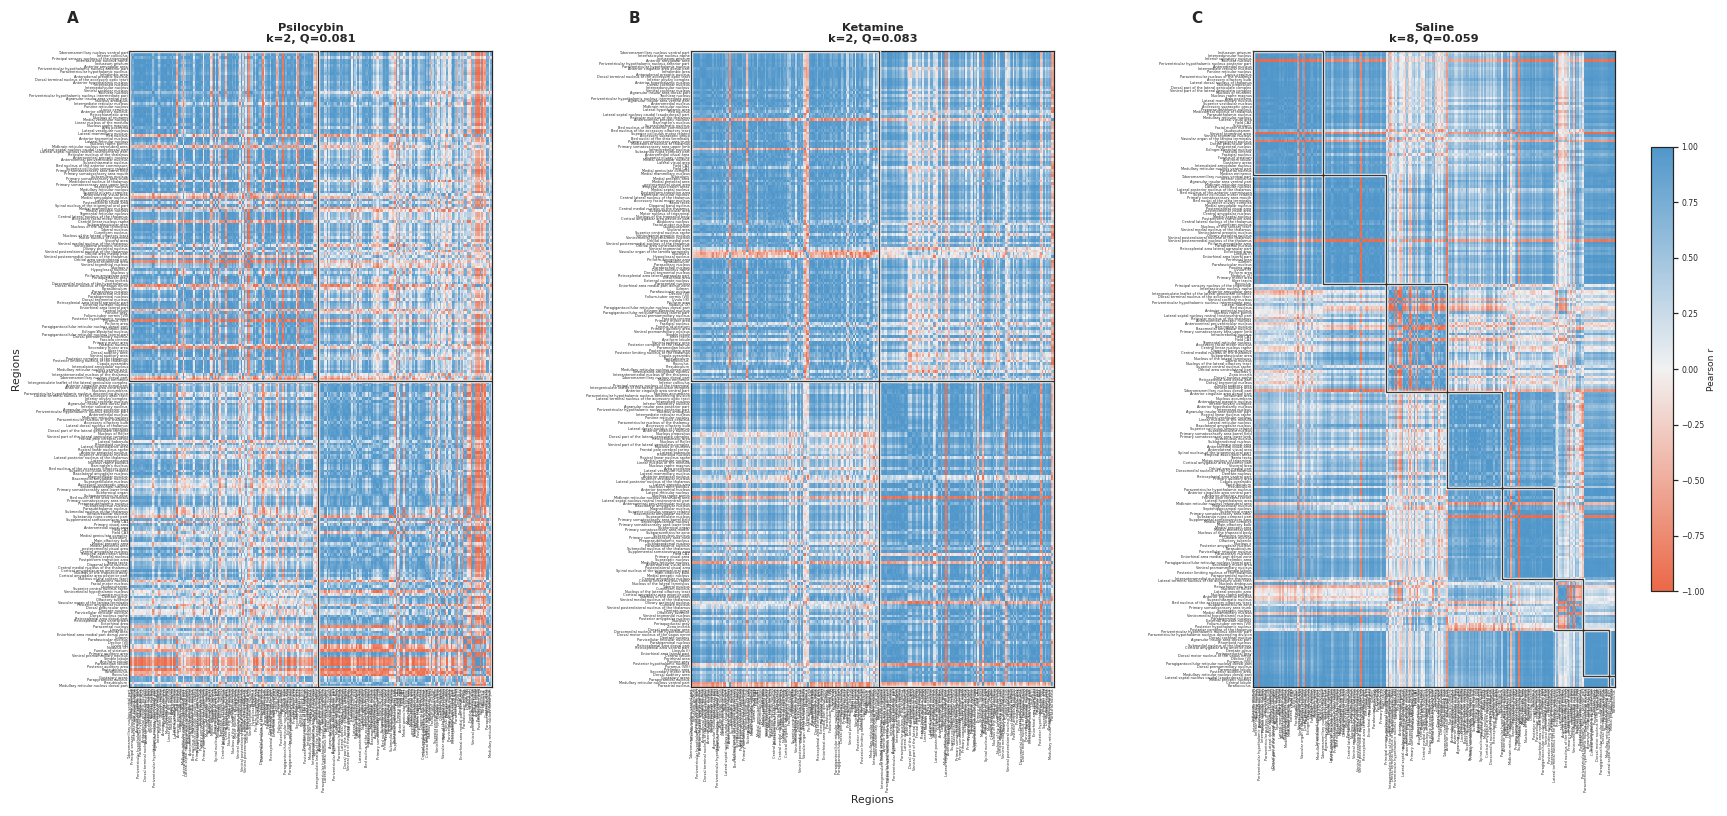

  Saved Brain_net_output/fig1_correlation_matrices.svg


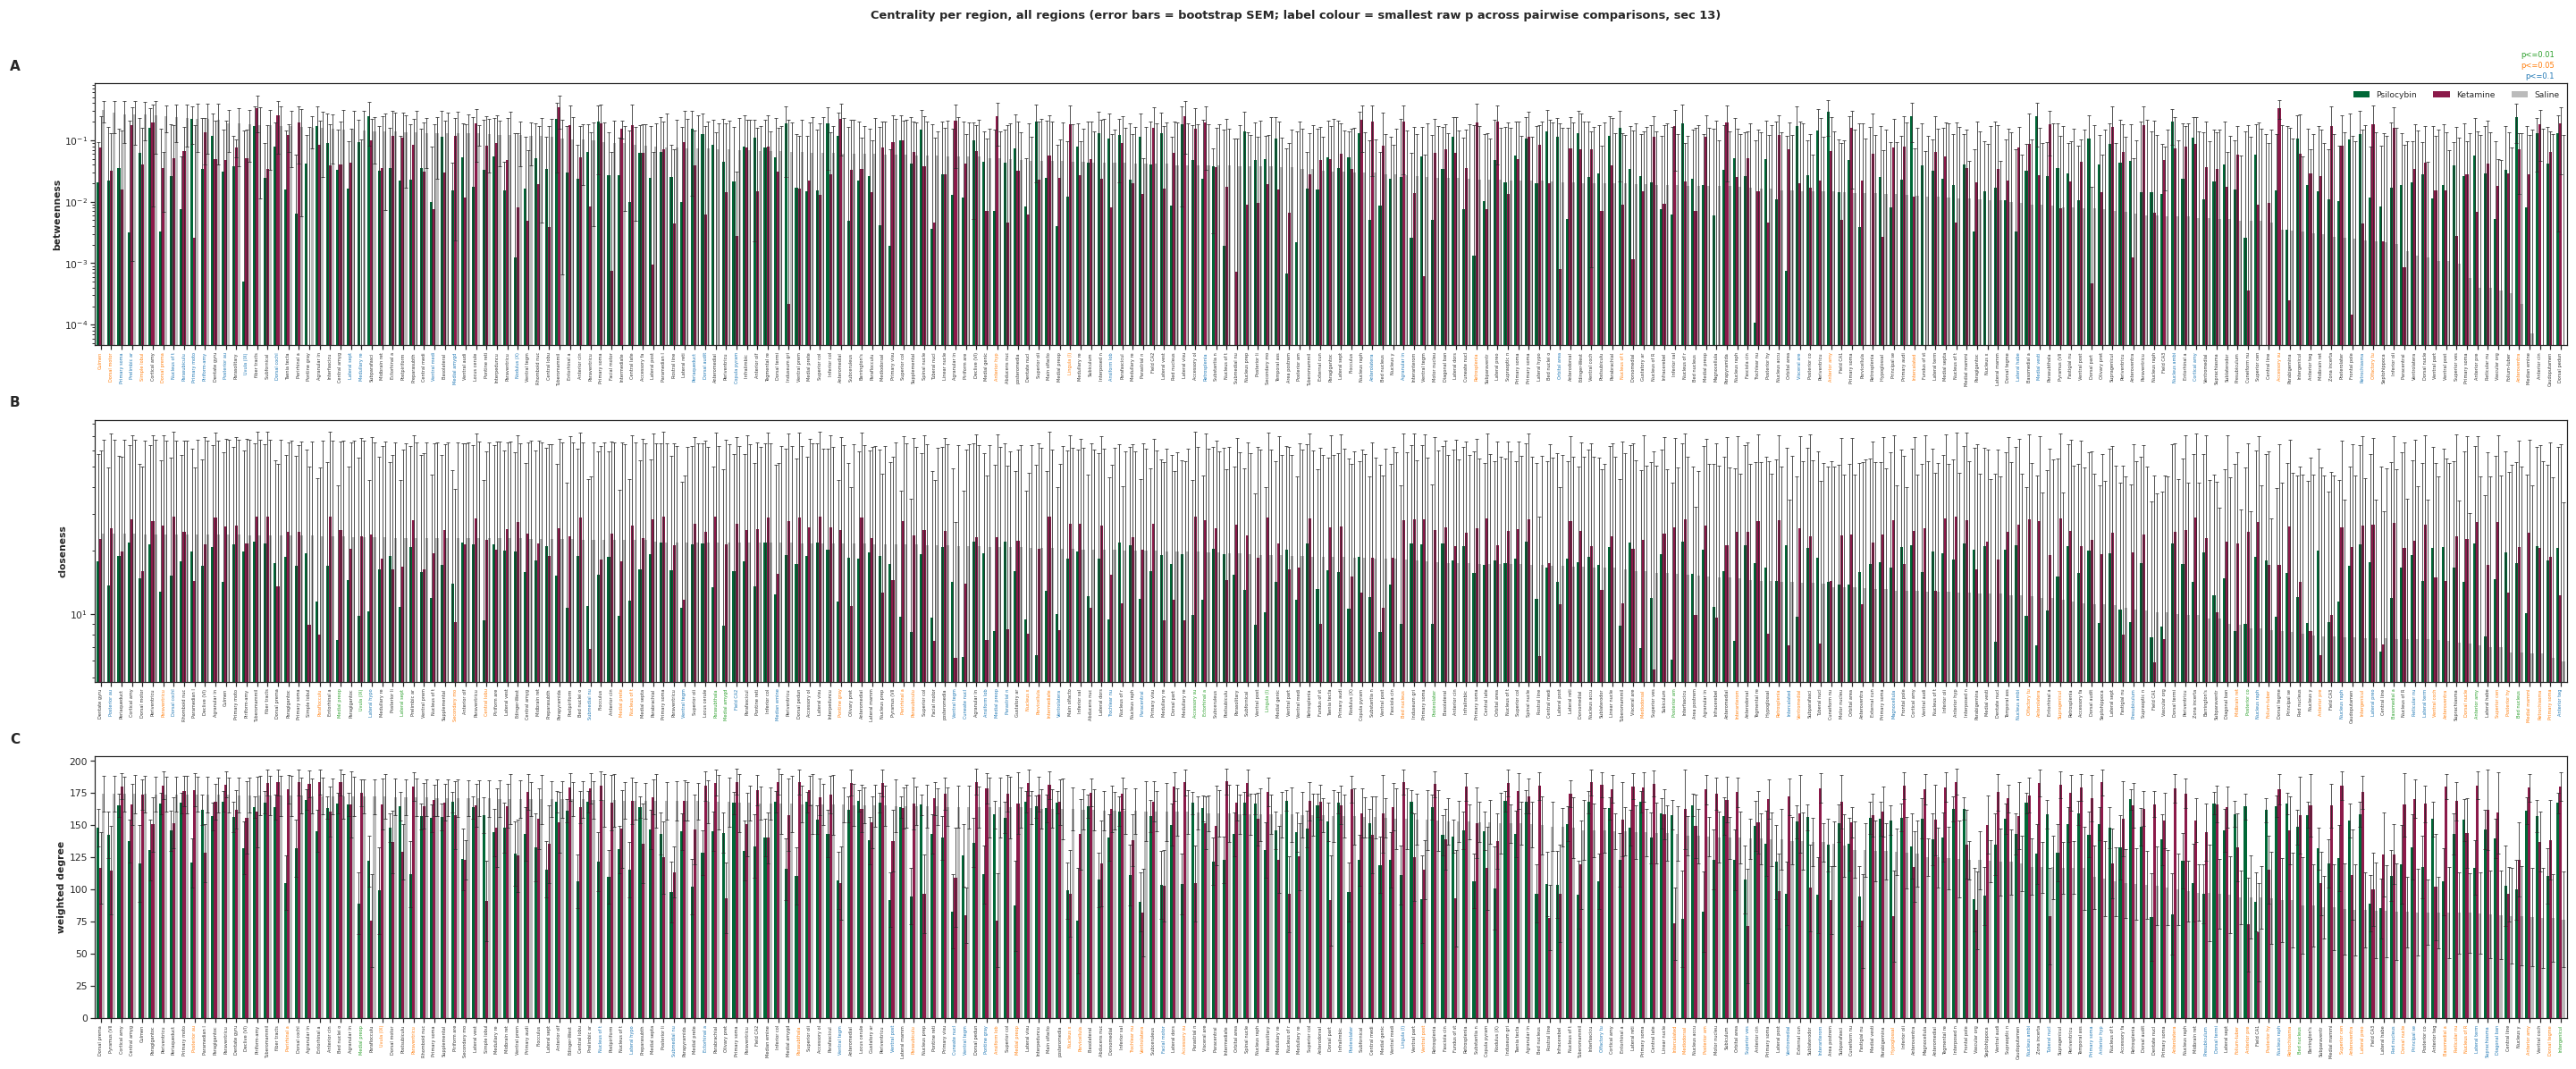

  Saved Brain_net_output/fig2_centrality_allregions.svg


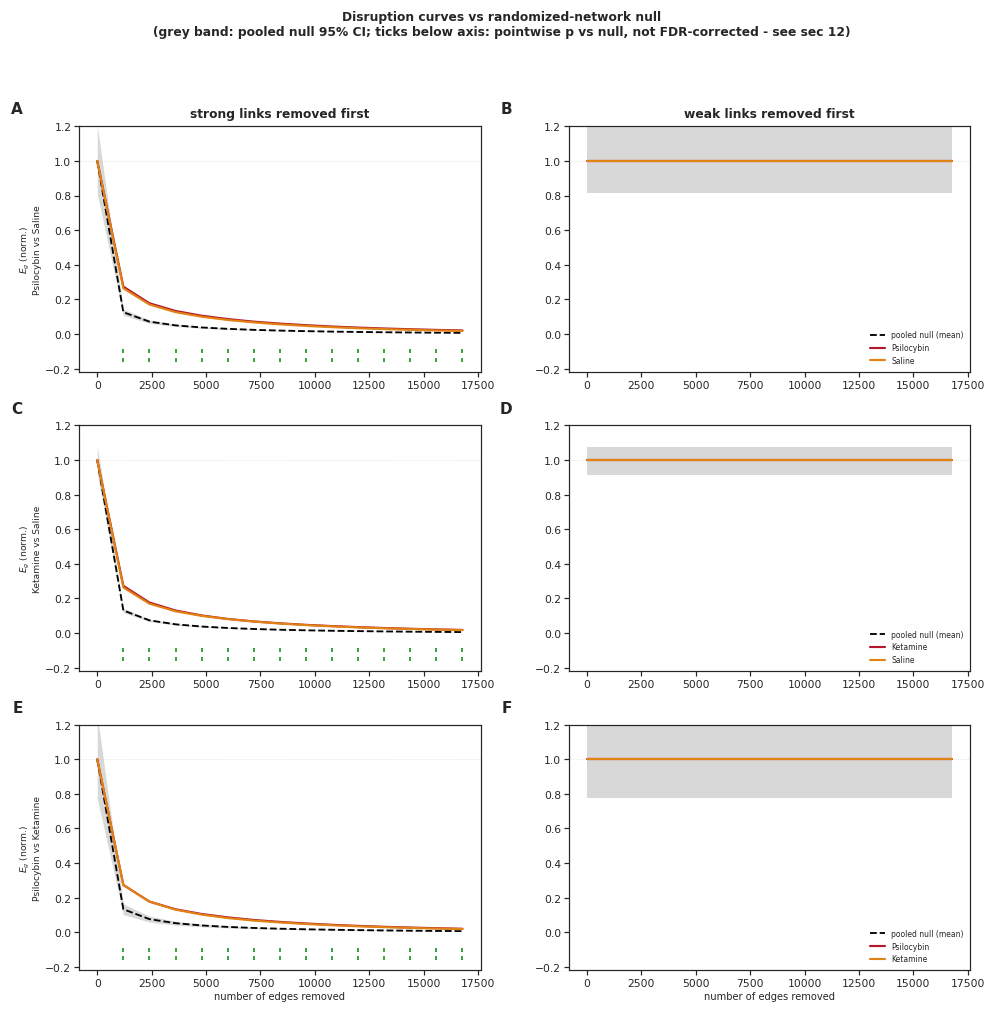

  Saved Brain_net_output/fig3_disruption_curves.svg


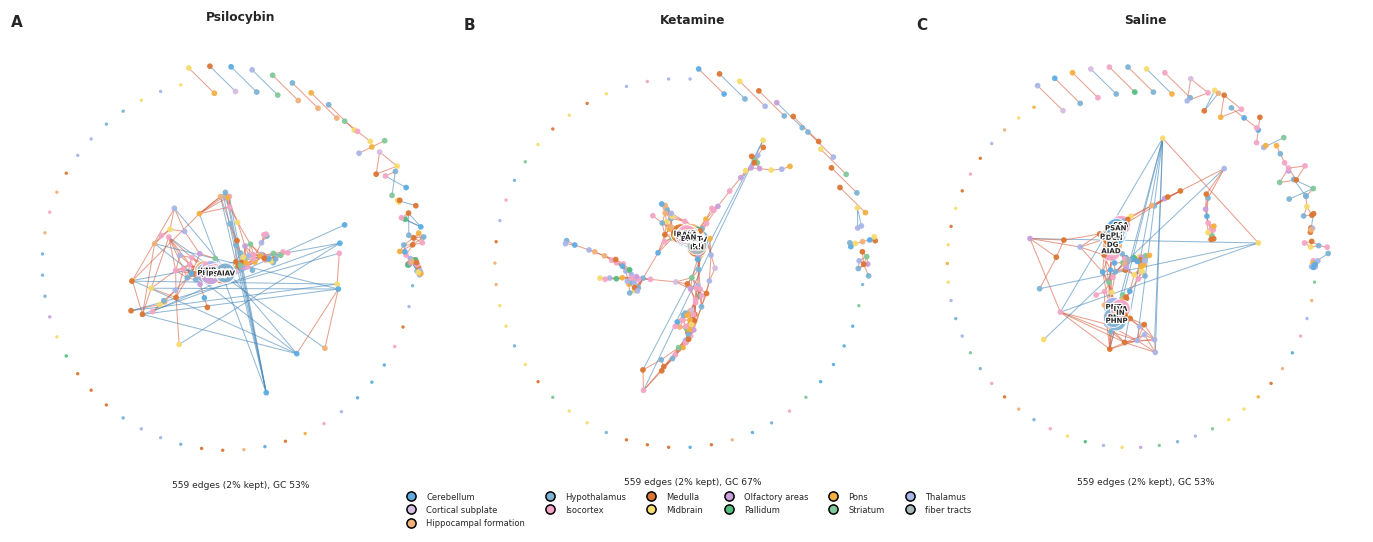

  Saved Brain_net_output/fig4_backbone_spring.svg


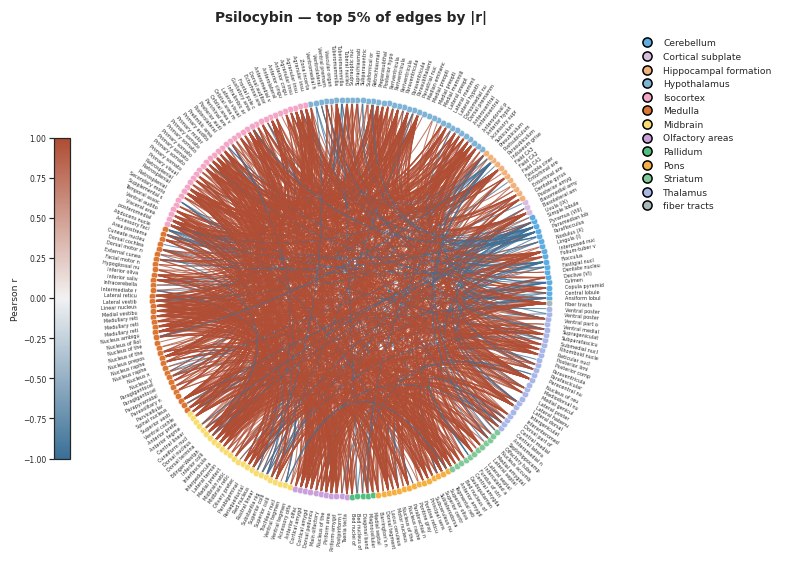

  Saved Brain_net_output/fig5_chord_PSI.svg


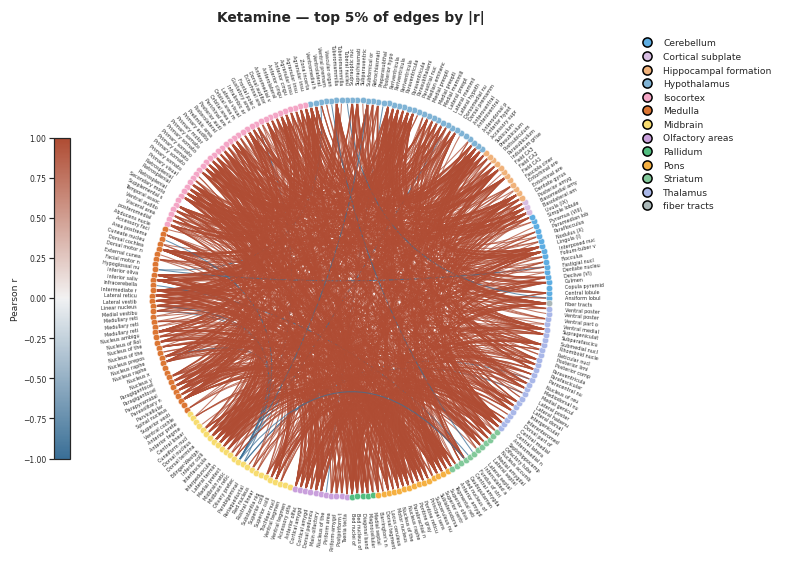

  Saved Brain_net_output/fig5_chord_KET.svg


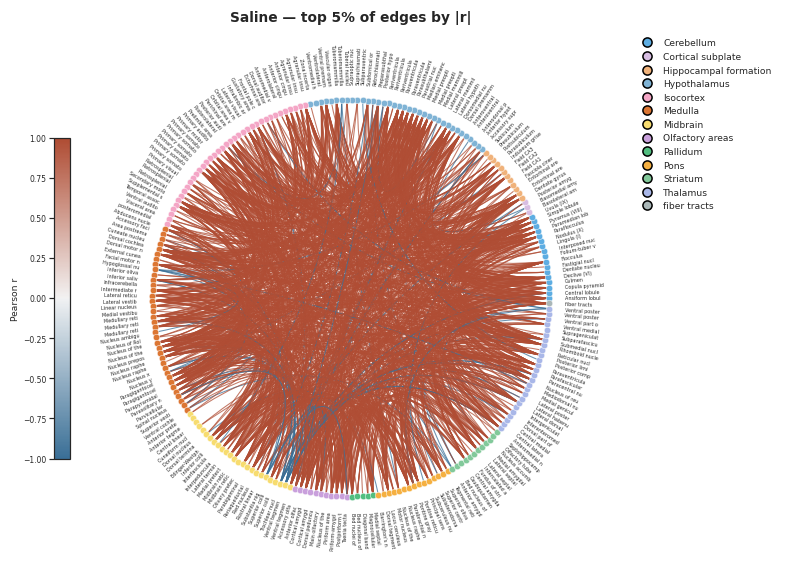

  Saved Brain_net_output/fig5_chord_SAL.svg


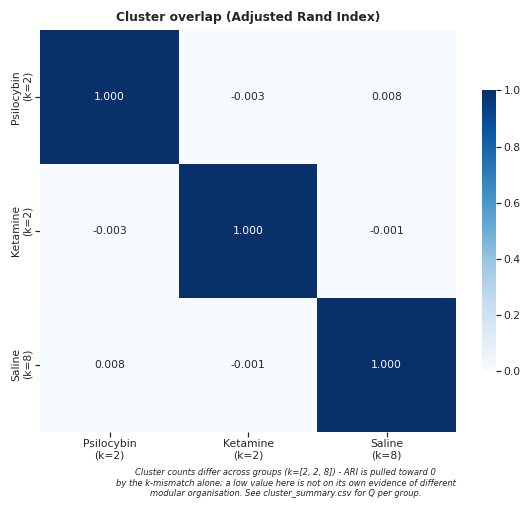

  Saved Brain_net_output/fig6_cluster_overlap.svg


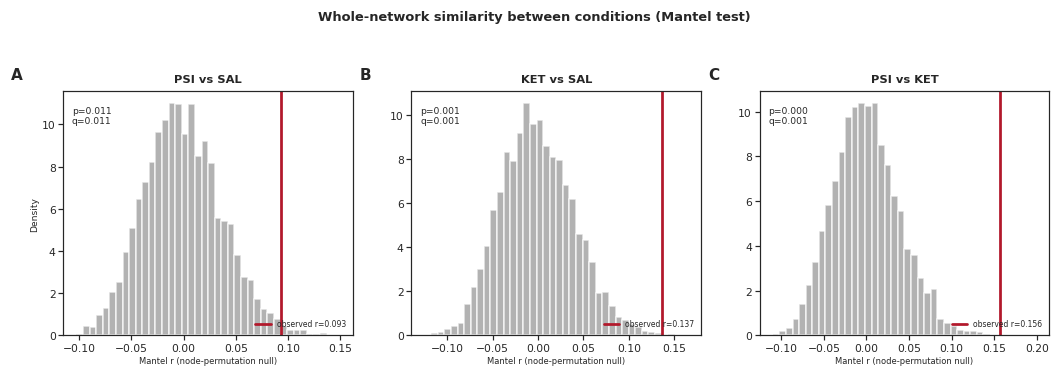

  Saved Brain_net_output/fig7_mantel_summary.svg


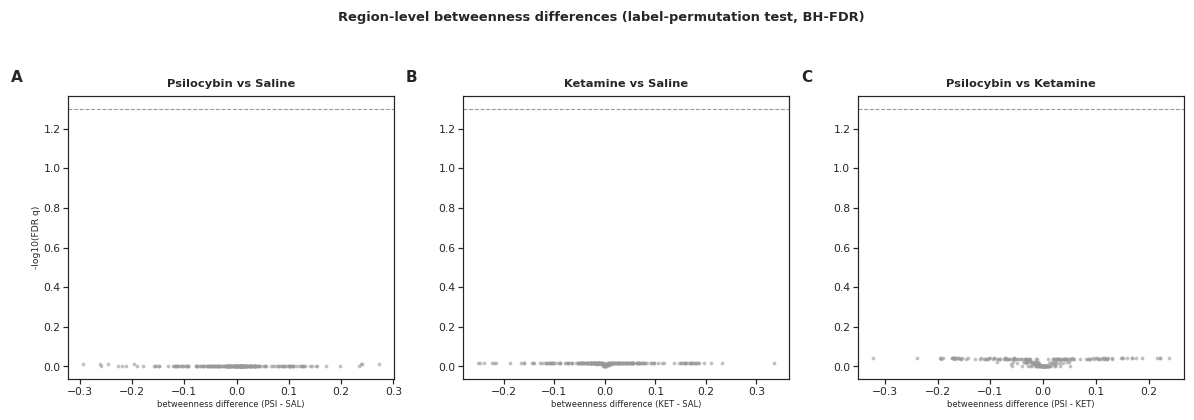

  Saved Brain_net_output/fig8_region_volcano_betweenness.svg


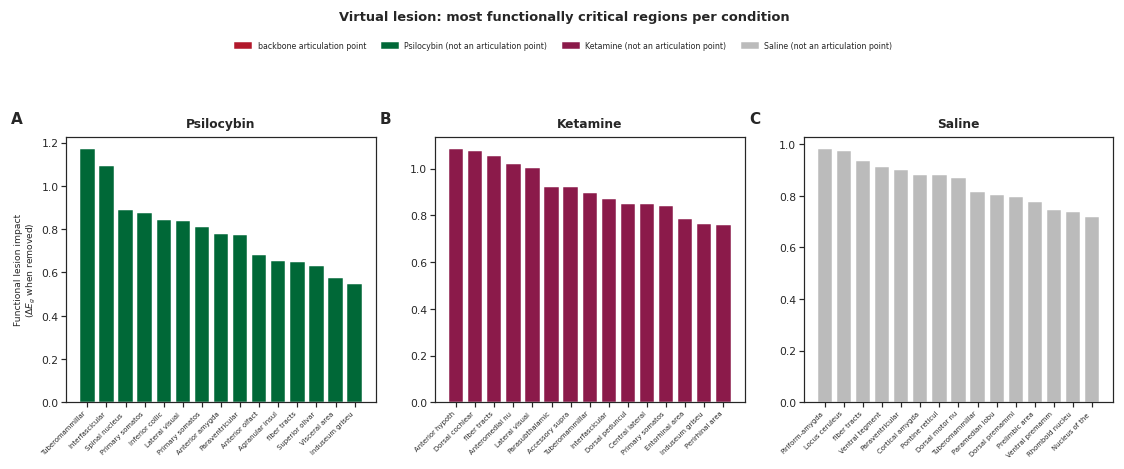

  Saved Brain_net_output/fig9_lesion_impact.svg


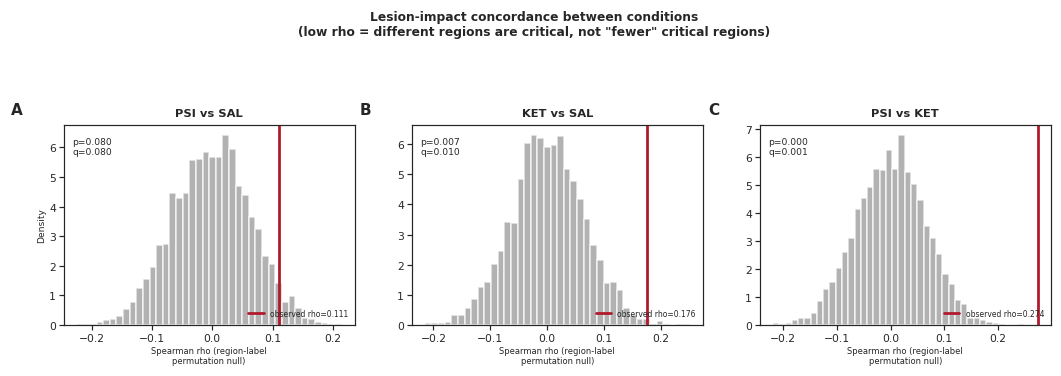

  Saved Brain_net_output/fig10_lesion_concordance.svg

All figures regenerated in Brain_net_output


In [25]:
groups            = results['groups']
clusters          = results['clusters']
region_labels     = results['region_labels']
region_categories = results['region_categories']
cent              = results['centrality']
region_stats      = results['region_stats']
disruption        = results['disruption']
disruption_sig    = results['disruption_significance']
backbones         = results['backbones']
lesion            = results['lesion']
graphs            = results['graphs']
mantel            = results['mantel']
concordance       = results['concordance']

cent_boot = bootstrap_centrality_ci(groups)  # fresh pass, needed for the new SEM field

figure_1_correlation_matrices(groups, clusters, region_labels, OUT_DIR)

figure_2_centrality_allregions(cent, region_labels, OUT_DIR,
                               centrality_boot=cent_boot, region_stats=region_stats)

if disruption:
    figure_3_disruption_curves(disruption, disruption_sig, OUT_DIR)
else:
    print("  [fig3 skipped - disruption null model not computed]")

figure_4_backbone_spring(backbones, region_labels, region_categories, OUT_DIR)

for drug in DRUG_ORDER:
    if drug in graphs:
        figure_chord_diagram(graphs[drug], region_labels, region_categories, OUT_DIR,
                             DRUG_META[drug]['label'], filename=f'fig5_chord_{drug}.svg')

figure_6_cluster_overlap(clusters, region_labels, OUT_DIR)

figure_7_mantel_summary(mantel, OUT_DIR)

if region_stats:
    figure_8_region_volcano(region_stats, region_labels, OUT_DIR, metric='betweenness')
else:
    print("  [fig8 skipped - region_stats not computed]")

figure_9_lesion_impact(lesion, region_labels, OUT_DIR)

figure_10_lesion_concordance(concordance, OUT_DIR)

print("\nAll figures regenerated in", OUT_DIR)